# Phase 05 — Initialization Preflight

This notebook validates only frozen inputs and upstream interfaces. It contains no HDC encoding, random hypervector generation, model fitting, prediction, or parameter search.

In [1]:
from pathlib import Path
import hashlib, importlib.metadata, importlib.util, json, os, platform, sys
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

PHASE = Path.cwd()
ROOT = PHASE.parents[1]
PRIMARY = ROOT / 'experiments/phase_03_multimodal_dataset_labeling/data/primary_without_performance.csv'
FOLDS = ROOT / 'experiments/phase_03_multimodal_dataset_labeling/data/fold_assignments.csv'
PHASE04A_FREEZE = ROOT / 'experiments/phase_04a_traditional_classification_baselines/configs/phase04a_freeze.json'
PHASE04A_COMPARISON = ROOT / 'experiments/phase_04a_traditional_classification_baselines/results/summaries/phase04a_final_classifier_comparison.csv'
PHASE04B_FREEZE = ROOT / 'experiments/phase_04b_traditional_regression_baselines/configs/phase04b_freeze.json'
PHASE04B_COMPARISON = ROOT / 'experiments/phase_04b_traditional_regression_baselines/results/summaries/phase04b_final_regressor_comparison.csv'
EXPECTED_PRIMARY_SHA = '0a2aef89c01b43c3a4e5afe40b96797784627665490982731b2541f96b45fc44'
EXPECTED_FOLD_SHA = 'e4dc943af21851bace49345f6336f9c88f82613ca3a26b3c433efe7dfb041f6f'
def sha256(path): return hashlib.sha256(path.read_bytes()).hexdigest()
def write_json(path, payload): path.write_text(json.dumps(payload, indent=2, ensure_ascii=False) + '\n', encoding='utf-8')
print('Phase 05 preflight paths prepared; no model or HDC operation is defined.')

Phase 05 preflight paths prepared; no model or HDC operation is defined.


In [2]:
primary_sha = sha256(PRIMARY)
fold_sha = sha256(FOLDS)
df = pd.read_csv(PRIMARY)
folds = pd.read_csv(FOLDS)
non_predictive = ['subject_id', 'session_id', 'run_id', 'difficulty_level_raw', 'difficulty_level', 'run_key', 'target_class', 'target_score', 'outer_fold']
predictive_features = [column for column in df.columns if column not in non_predictive]
run_key_alignment = set(df['run_key']) == set(folds['run_key']) and df['run_key'].is_unique and folds['run_key'].is_unique
merged = df[['run_key', 'subject_id', 'outer_fold']].merge(folds[['run_key', 'subject_id', 'outer_fold']], on='run_key', validate='one_to_one', suffixes=('_primary', '_fold'))
fold_metadata_agreement = bool((merged['subject_id_primary'] == merged['subject_id_fold']).all() and (merged['outer_fold_primary'] == merged['outer_fold_fold']).all())
outer_checks = []
for fold in sorted(folds['outer_fold'].unique()):
    test_subjects = set(folds.loc[folds['outer_fold'] == fold, 'subject_id'])
    train_subjects = set(folds.loc[folds['outer_fold'] != fold, 'subject_id'])
    train = folds.loc[folds['outer_fold'] != fold]
    inner_splits = list(GroupKFold(n_splits=3).split(train, groups=train['subject_id']))
    inner_subject_isolation = all(not (set(train.iloc[a]['subject_id']) & set(train.iloc[b]['subject_id'])) for a, b in inner_splits)
    outer_checks.append({'outer_fold': int(fold), 'train_subjects': len(train_subjects), 'test_subjects': len(test_subjects), 'subject_overlap': len(train_subjects & test_subjects), 'inner_groupkfold_splits': len(inner_splits), 'inner_subject_isolation': bool(inner_subject_isolation)})
input_audit = {
    'phase': '05', 'audit_type': 'input_and_fold_preflight',
    'primary': {'path': str(PRIMARY), 'sha256': primary_sha, 'expected_sha256': EXPECTED_PRIMARY_SHA, 'checksum_pass': primary_sha == EXPECTED_PRIMARY_SHA, 'rows': int(len(df)), 'subjects': int(df['subject_id'].nunique()), 'predictive_features': int(len(predictive_features)), 'run_key_missing': int(df['run_key'].isna().sum()), 'run_key_unique': bool(df['run_key'].is_unique), 'target_class_values': sorted(int(v) for v in df['target_class'].dropna().unique()), 'target_class_missing': int(df['target_class'].isna().sum()), 'target_score_values': sorted(float(v) for v in df['target_score'].dropna().unique()), 'target_score_missing': int(df['target_score'].isna().sum()), 'class_equals_score_minus_one': bool((df['target_class'] == df['target_score'] - 1).all())},
    'frozen_fold_assignments': {'path': str(FOLDS), 'sha256': fold_sha, 'expected_sha256': EXPECTED_FOLD_SHA, 'checksum_pass': fold_sha == EXPECTED_FOLD_SHA, 'rows': int(len(folds)), 'outer_folds': int(folds['outer_fold'].nunique()), 'run_key_one_to_one_alignment': bool(run_key_alignment), 'fold_metadata_agreement': fold_metadata_agreement, 'outer_fold_checks': outer_checks, 'outer_subject_isolation_pass': all(item['subject_overlap'] == 0 for item in outer_checks), 'inner_3fold_groupkfold_feasibility_pass': all(item['inner_groupkfold_splits'] == 3 and item['inner_subject_isolation'] for item in outer_checks)},
    'prohibited_operations_executed': {'random_hypervector_generation': False, 'preprocessor_fitting': False, 'outer_test_design_access': False, 'fold_regeneration': False}
}
write_json(PHASE / 'audits/phase05_input_and_fold_audit.json', input_audit)
print(json.dumps(input_audit, indent=2))

{
  "phase": "05",
  "audit_type": "input_and_fold_preflight",
  "primary": {
    "path": "E:\\hdc-vr-pilot\\experiments\\phase_03_multimodal_dataset_labeling\\data\\primary_without_performance.csv",
    "sha256": "0a2aef89c01b43c3a4e5afe40b96797784627665490982731b2541f96b45fc44",
    "expected_sha256": "0a2aef89c01b43c3a4e5afe40b96797784627665490982731b2541f96b45fc44",
    "checksum_pass": true,
    "rows": 419,
    "subjects": 35,
    "predictive_features": 1176,
    "run_key_missing": 0,
    "run_key_unique": true,
    "target_class_values": [
      0,
      1,
      2,
      3
    ],
    "target_class_missing": 0,
    "target_score_values": [
      1.0,
      2.0,
      3.0,
      4.0
    ],
    "target_score_missing": 0,
    "class_equals_score_minus_one": true
  },
  "frozen_fold_assignments": {
    "path": "E:\\hdc-vr-pilot\\experiments\\phase_03_multimodal_dataset_labeling\\data\\fold_assignments.csv",
    "sha256": "e4dc943af21851bace49345f6336f9c88f82613ca3a26b3c433efe7dfb041

In [3]:
phase04a_freeze = json.loads(PHASE04A_FREEZE.read_text(encoding='utf-8'))
phase04b_freeze = json.loads(PHASE04B_FREEZE.read_text(encoding='utf-8'))
phase04a_table = pd.read_csv(PHASE04A_COMPARISON)
phase04b_table = pd.read_csv(PHASE04B_COMPARISON)
best_classifier = phase04a_table.sort_values('oof_macro_f1', ascending=False).iloc[0].to_dict()
best_regressor = phase04b_table.sort_values('mae_bounded', ascending=True).iloc[0].to_dict()
phase04a_pass = bool(phase04a_freeze.get('phase04a_status') == 'COMPLETE' and phase04a_freeze.get('phase04a_frozen') == 'YES')
phase04b_sha_pass = bool(phase04b_freeze.get('primary_input', {}).get('sha256') == primary_sha and phase04b_freeze.get('frozen_fold', {}).get('sha256') == fold_sha)
phase04b_pass = bool(phase04b_freeze.get('status') == 'FROZEN' and phase04b_sha_pass)
upstream_audit = {'phase': '05', 'phase04a': {'freeze_path': str(PHASE04A_FREEZE), 'parseable': True, 'status': phase04a_freeze.get('phase04a_status'), 'frozen': phase04a_freeze.get('phase04a_frozen'), 'interface_pass': phase04a_pass, 'best_traditional_classifier': best_classifier}, 'phase04b': {'freeze_path': str(PHASE04B_FREEZE), 'parseable': True, 'status': phase04b_freeze.get('status'), 'primary_sha_matches_actual': phase04b_freeze.get('primary_input', {}).get('sha256') == primary_sha, 'fold_sha_matches_actual': phase04b_freeze.get('frozen_fold', {}).get('sha256') == fold_sha, 'interface_pass': phase04b_pass, 'best_traditional_regressor': best_regressor}}
write_json(PHASE / 'audits/phase05_upstream_freeze_audit.json', upstream_audit)
packages = {name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'jupyter']}
hdc_libraries = {name: importlib.util.find_spec(name) is not None for name in ['torchhd', 'hdlib', 'pyhdc']}
environment = {'phase': '05', 'python': sys.version, 'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': packages['scipy'], 'scikit_learn': packages['scikit-learn'], 'jupyter': packages['jupyter'], 'operating_system': platform.platform(), 'cpu': {'processor': platform.processor(), 'processor_identifier': os.environ.get('PROCESSOR_IDENTIFIER'), 'logical_cpu_count': os.cpu_count()}, 'hdc_specialized_library_availability': hdc_libraries, 'approved_default_implementation': 'audited NumPy/scikit-learn self-implementation permitted; no dependency installed'}
write_json(PHASE / 'audits/phase05_environment_audit.json', environment)
write_json(PHASE / 'configs/phase05_environment.json', environment)
report = '# Phase 05 initialization report\n\n## Status\n\nInitialized / not trained. This report records preflight evidence only; no HDC model, encoder, random hypervector, preprocessing fit, prediction, OOF generation, or parameter search was executed.\n\n## Frozen inputs\n\n- Primary SHA-256: `' + primary_sha + '` (pass: ' + str(input_audit['primary']['checksum_pass']) + ')\n- Frozen-fold SHA-256: `' + fold_sha + '` (pass: ' + str(input_audit['frozen_fold_assignments']['checksum_pass']) + ')\n- Modeling rows / subjects / predictive features: 419 / 35 / 1176.\n\n## Upstream comparison references\n\n- Phase 04A: ' + str(best_classifier['model']) + ', OOF Macro-F1=' + str(best_classifier['oof_macro_f1']) + '.\n- Phase 04B: ' + str(best_regressor['model']) + ', bounded OOF MAE=' + str(best_regressor['mae_bounded']) + '.\n\nThese values are read-only comparison references; they did not select any HDC configuration.\n\n## Gate\n\nThe detailed HDC implementation contract remains `PENDING_CONTRACT_FREEZE`. No Vanilla HDC training may begin until it is frozen.\n'
(PHASE / 'reports/phase05_initialization_report.md').write_text(report, encoding='utf-8')
print(json.dumps(upstream_audit, indent=2))
print(json.dumps(environment, indent=2))

{
  "phase": "05",
  "phase04a": {
    "freeze_path": "E:\\hdc-vr-pilot\\experiments\\phase_04a_traditional_classification_baselines\\configs\\phase04a_freeze.json",
    "parseable": true,
    "status": "COMPLETE",
    "frozen": "YES",
    "interface_pass": true,
    "best_traditional_classifier": {
      "model": "Gradient Boosting",
      "model_slug": "gradient_boosting",
      "oof_macro_f1": 0.9356075023489924,
      "oof_balanced_accuracy": 0.9356862084456424,
      "oof_accuracy": 0.935560859188544,
      "oof_weighted_f1": 0.9356374078190548,
      "recall_class_0": 0.9423076923076924,
      "recall_class_1": 0.8867924528301887,
      "recall_class_2": 0.9326923076923076,
      "recall_class_3": 0.9809523809523808,
      "fold_macro_f1_mean": 0.9358879181084316,
      "fold_macro_f1_std": 0.0189540639634232
    }
  },
  "phase04b": {
    "freeze_path": "E:\\hdc-vr-pilot\\experiments\\phase_04b_traditional_regression_baselines\\configs\\phase04b_freeze.json",
    "parseable": tr

In [4]:
print('PHASE 05 INITIALIZATION STATUS: INITIALIZED_NOT_TRAINED')

PHASE 05 INITIALIZATION STATUS: INITIALIZED_NOT_TRAINED


## Contract-freeze static validation

This cell loads and checks only JSON contracts. It does not instantiate or fit a model, generate a hypervector, encode data, search parameters, or make predictions.

In [5]:
contract_files = [PHASE / 'configs/phase05_experiment_contract.json', PHASE / 'configs/phase05_hdc_search_space.json', PHASE / 'configs/phase05_hdc_encoding_contract.json', PHASE / 'configs/phase05_hdc_model_selection_contract.json', PHASE / 'configs/phase05_hdc_regression_heads_contract.json', PHASE / 'configs/phase05_hdc_efficiency_protocol.json']
contracts = {path.name: json.loads(path.read_text(encoding='utf-8')) for path in contract_files}
search = contracts['phase05_hdc_search_space.json']; encoding = contracts['phase05_hdc_encoding_contract.json']; selection = contracts['phase05_hdc_model_selection_contract.json']; heads = contracts['phase05_hdc_regression_heads_contract.json']; efficiency = contracts['phase05_hdc_efficiency_protocol.json']
candidate_count = len(search['rapid_screening']['dimensions']) * len(search['rapid_screening']['levels']) * len(search['rapid_screening']['feature_selection__k']) * len(search['rapid_screening']['seeds'])
assert candidate_count == 16
assert search['rapid_screening']['dimensions'] == [2000, 5000] and search['rapid_screening']['levels'] == [21, 51]
assert search['final_confirmation']['dimensions'] == [1000, 2000, 5000, 10000] and search['final_confirmation']['seeds'] == [42, 43, 44, 45, 46]
assert encoding['representation']['type'] == 'bipolar' and encoding['representation']['item_level_sample_dtype'] == 'int8' and encoding['representation']['bundle_accumulator_dtype'] == 'int32' and encoding['representation']['prototype_and_similarity_dtype'] == 'float32'
assert all(value > 0 for value in heads['similarity_weighted_regression']['temperature_grid']) and all(value > 0 for value in heads['ridge_hypervector_readout']['alpha_grid'])
assert len(heads['similarity_weighted_regression']['tie_breaking']) == 4 and len(heads['ridge_hypervector_readout']['tie_breaking']) == 4
assert selection['outer_test_rule'] and encoding['preprocessing']['outer_test_excluded_from_all_preprocessing_and_selection']
excluded = set(search['scope_exclusions']); assert {'OnlineHD-style HDC', 'Multi-centroid HDC', 'HDC+OnlineHD Hybrid', 'Phase 06 variants'} <= excluded
result_files = [str(path.relative_to(PHASE)) for path in (PHASE / 'results').rglob('*') if path.is_file()]
assert not result_files
upstream_hashes = {str(path): sha256(path) for path in [PRIMARY, FOLDS, PHASE04A_FREEZE, PHASE04A_COMPARISON, PHASE04B_FREEZE, PHASE04B_COMPARISON]}
freeze_audit = {'phase': '05', 'status': 'CONTRACT_FROZEN_NOT_TRAINED', 'initialization_gate_pass': bool(input_audit['primary']['checksum_pass'] and input_audit['frozen_fold_assignments']['checksum_pass'] and phase04a_pass and phase04b_pass), 'source_file_hashes_observed_read_only': upstream_hashes, 'training_executed': False, 'hypervectors_generated': False, 'prototypes_built': False, 'parameter_search_executed': False, 'predictions_generated': False, 'oof_generated': False}
static_validation = {'phase': '05', 'json_parse_pass': True, 'rapid_candidate_count': candidate_count, 'rapid_candidate_count_pass': candidate_count == 16, 'dimensions_and_levels_pass': True, 'seeds_pass': True, 'positive_temperature_grid_pass': True, 'positive_ridge_alpha_grid_pass': True, 'dtype_definitions_complete_pass': True, 'tie_breaking_complete_pass': True, 'outer_test_selection_prohibition_pass': True, 'phase06_variants_excluded_pass': True, 'result_artifacts_absent_pass': not result_files, 'result_files': result_files, 'source_inputs_read_only_pass': True, 'static_validation_result': 'PASS'}
write_json(PHASE / 'audits/phase05_hdc_contract_freeze_audit.json', freeze_audit)
write_json(PHASE / 'audits/phase05_hdc_contract_static_validation.json', static_validation)
report = '# Phase 05 HDC contract freeze report\n\n## Status\n\n`CONTRACT_FROZEN_NOT_TRAINED`. This is a static contract freeze only. No HDC model fit, hypervector generation, encoding, prototype construction, parameter search, prediction, or OOF artifact was executed.\n\n## Frozen design\n\n- Representation: bipolar `[-1, +1]`; item/level/sample arrays are `int8`, accumulators `int32`, and normalized prototype/similarity arrays `float32`.\n- Shared encoder candidates: 16 combinations of dimensions `[2000, 5000]`, levels `[21, 51]`, k `[50, 100, 200, all]`, and seed `42`.\n- Final-confirmation plan: dimensions `[1000, 2000, 5000, 10000]`; seeds `[42, 43, 44, 45, 46]`; not executed.\n- Similarity temperature grid: `[0.05, 0.1, 0.2, 0.5, 1.0, 2.0]`. Ridge alpha grid: `[0.01, 0.1, 1.0, 10.0, 100.0]`.\n\n## Static gate\n\nAll JSON contracts parsed, selection-space checks passed, outer-test selection is prohibited, Phase 06 variants are excluded, and every results subdirectory remains file-empty. The next authorized operation is the Vanilla HDC quick screen under this frozen contract.\n'
(PHASE / 'reports/phase05_hdc_contract_freeze_report.md').write_text(report, encoding='utf-8')
print(json.dumps(static_validation, indent=2))

{
  "phase": "05",
  "json_parse_pass": true,
  "rapid_candidate_count": 16,
  "rapid_candidate_count_pass": true,
  "dimensions_and_levels_pass": true,
  "seeds_pass": true,
  "positive_temperature_grid_pass": true,
  "positive_ridge_alpha_grid_pass": true,
  "dtype_definitions_complete_pass": true,
  "tie_breaking_complete_pass": true,
  "outer_test_selection_prohibition_pass": true,
  "phase06_variants_excluded_pass": true,
  "result_artifacts_absent_pass": true,
  "result_files": [],
  "source_inputs_read_only_pass": true,
  "static_validation_result": "PASS"
}


In [6]:
print('PHASE 05 HDC CONTRACT FREEZE STATUS: CONTRACT_FROZEN_NOT_TRAINED')

PHASE 05 HDC CONTRACT FREEZE STATUS: CONTRACT_FROZEN_NOT_TRAINED


## Outer Fold 1 Vanilla HDC quick-screen evidence

This section only reads saved Fold 1 checkpoint, candidate summary, best configuration, and audits. It does not rerun screening or read outer-test predictions/features.

In [1]:
from pathlib import Path
import json
import pandas as pd
PHASE = Path.cwd()
checkpoint = json.loads((PHASE / 'results/checkpoints/quick_screen/vanilla_hdc_quick_screen_fold_1_checkpoint.json').read_text(encoding='utf-8'))
candidate_summary = pd.read_csv(PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_1_candidates.csv')
best_config = json.loads((PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_1_best_config.json').read_text(encoding='utf-8'))
leakage_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_1_leakage_audit.json').read_text(encoding='utf-8'))
artifact_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_1_artifact_audit.json').read_text(encoding='utf-8'))
display(candidate_summary[['dimension', 'levels', 'k', 'mean_macro_f1', 'std_macro_f1', 'mean_balanced_accuracy', 'mean_severe_error_rate']].sort_values('mean_macro_f1', ascending=False).reset_index(drop=True))
print(json.dumps({'best_config': best_config, 'checkpoint_overall_pass': checkpoint['overall_pass'], 'leakage_audit': leakage_audit['result'], 'artifact_audit': artifact_audit['result'], 'outer_test_feature_access': checkpoint['outer_test_feature_access']}, indent=2))

,dimension,levels,k,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,mean_severe_error_rate
0,2000,51,50,0.799210,0.080203,0.804086,0.036466
1,5000,21,50,0.795799,0.092256,0.801213,0.039553
2,2000,21,50,0.793325,0.072745,0.798978,0.039268
3,5000,51,50,0.793209,0.098217,0.798524,0.042354
4,5000,21,200,0.769616,0.024924,0.776030,0.045726
5,5000,21,100,0.765469,0.087406,0.772820,0.048812
6,2000,21,100,0.760857,0.103414,0.768965,0.048527
7,2000,21,200,0.760749,0.057816,0.768885,0.054129
8,2000,51,100,0.752815,0.068232,0.760687,0.045440
9,5000,51,100,0.741612,0.081317,0.751243,0.042639


{
  "best_config": {
    "outer_fold": 1,
    "dimension": 2000,
    "levels": 51,
    "k": "50",
    "effective_k": 50,
    "seed": 42,
    "effective_k_by_inner_fold": "[50, 50, 50]",
    "inner_fold_1_macro_f1": 0.8622315184815186,
    "inner_fold_2_macro_f1": 0.6860294117647059,
    "inner_fold_3_macro_f1": 0.8493691615402141,
    "mean_macro_f1": 0.7992100305954795,
    "std_macro_f1": 0.08020286535076344,
    "mean_balanced_accuracy": 0.8040861588321729,
    "mean_accuracy": 0.8039475049278971,
    "mean_severe_error_rate": 0.03646643842722274,
    "mean_recall_class_0": 0.753937845891869,
    "mean_recall_class_1": 0.7025089605734767,
    "mean_recall_class_2": 0.7598978288633461,
    "mean_recall_class_3": 1.0,
    "encoding_time_seconds": 0.8644566999864765,
    "prototype_training_time_seconds": 0.002226300013717264,
    "inference_time_seconds": 0.0025633999903220683,
    "model_bytes": 300224,
    "codebook_hashes": "[\"{\\\"identity_codebook_sha256\\\": \\\"862f682cd055f6c

In [2]:
print('PHASE 05 VANILLA HDC QUICK SCREEN FOLD 1: COMPLETE')

PHASE 05 VANILLA HDC QUICK SCREEN FOLD 1: COMPLETE


## Outer Fold 2 Vanilla HDC quick-screen evidence

This section only reads saved Fold 2 checkpoint, candidate summary, best configuration, and audits. It does not rerun screening, alter Fold 1 outputs, or read outer-test predictions/features.

In [1]:
from pathlib import Path
import json
import pandas as pd
PHASE = Path.cwd()
fold2_checkpoint = json.loads((PHASE / 'results/checkpoints/quick_screen/vanilla_hdc_quick_screen_fold_2_checkpoint.json').read_text(encoding='utf-8'))
fold2_candidate_summary = pd.read_csv(PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_2_candidates.csv')
fold2_best_config = json.loads((PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_2_best_config.json').read_text(encoding='utf-8'))
fold2_leakage_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_2_leakage_audit.json').read_text(encoding='utf-8'))
fold2_artifact_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_2_artifact_audit.json').read_text(encoding='utf-8'))
display(fold2_candidate_summary[['dimension', 'levels', 'k', 'mean_macro_f1', 'std_macro_f1', 'mean_balanced_accuracy', 'mean_severe_error_rate']].sort_values('mean_macro_f1', ascending=False).reset_index(drop=True))
print(json.dumps({'best_config': fold2_best_config, 'checkpoint_overall_pass': fold2_checkpoint['overall_pass'], 'fold1_artifacts_preserved': fold2_checkpoint['fold1_artifacts_preserved'], 'leakage_audit': fold2_leakage_audit['result'], 'artifact_audit': fold2_artifact_audit['result'], 'outer_test_feature_access': fold2_checkpoint['outer_test_feature_access']}, indent=2))

,dimension,levels,k,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,mean_severe_error_rate
0,5000,51,50,0.763385,0.006749,0.769817,0.038982
1,2000,51,50,0.757529,0.021419,0.764783,0.041783
2,5000,21,50,0.744173,0.030638,0.749585,0.044585
3,2000,21,50,0.742257,0.015909,0.748563,0.041498
4,2000,51,100,0.725810,0.035948,0.731971,0.047386
5,5000,51,100,0.725043,0.037979,0.729619,0.052988
6,2000,51,200,0.714373,0.044430,0.722073,0.050187
7,5000,51,200,0.703536,0.007646,0.713548,0.052988
8,2000,21,100,0.702450,0.028529,0.710696,0.047671
9,2000,21,200,0.685483,0.037042,0.695690,0.038982


{
  "best_config": {
    "outer_fold": 2,
    "dimension": 5000,
    "levels": 51,
    "k": "50",
    "effective_k": 50,
    "seed": 42,
    "effective_k_by_inner_fold": "[50, 50, 50]",
    "inner_fold_1_macro_f1": 0.7634028847388011,
    "inner_fold_2_macro_f1": 0.755109225101067,
    "inner_fold_3_macro_f1": 0.7716417910447761,
    "mean_macro_f1": 0.7633846336282147,
    "std_macro_f1": 0.006749404121750344,
    "mean_balanced_accuracy": 0.7698169433801617,
    "mean_accuracy": 0.7700487602448387,
    "mean_severe_error_rate": 0.03898225957049486,
    "mean_recall_class_0": 0.745679012345679,
    "mean_recall_class_1": 0.7209876543209877,
    "mean_recall_class_2": 0.6126011068539804,
    "mean_recall_class_3": 1.0,
    "encoding_time_seconds": 0.8622928999975557,
    "prototype_training_time_seconds": 0.004993499984266236,
    "inference_time_seconds": 0.006362300002365373,
    "model_bytes": 651504,
    "codebook_hashes": "[\"{\\\"identity_codebook_sha256\\\": \\\"3907fbd25d07d07a

In [2]:
print('PHASE 05 VANILLA HDC QUICK SCREEN FOLD 2: COMPLETE')

PHASE 05 VANILLA HDC QUICK SCREEN FOLD 2: COMPLETE


## Outer Fold 3 Vanilla HDC quick-screen evidence

This section only reads saved Fold 3 checkpoint, candidate summary, best configuration, and audits. It does not rerun screening, alter Fold 1–2 outputs, or read outer-test predictions/features.

In [1]:
from pathlib import Path
import json
import pandas as pd
PHASE = Path.cwd()
fold3_checkpoint = json.loads((PHASE / 'results/checkpoints/quick_screen/vanilla_hdc_quick_screen_fold_3_checkpoint.json').read_text(encoding='utf-8'))
fold3_candidate_summary = pd.read_csv(PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_3_candidates.csv')
fold3_best_config = json.loads((PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_3_best_config.json').read_text(encoding='utf-8'))
fold3_leakage_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_3_leakage_audit.json').read_text(encoding='utf-8'))
fold3_artifact_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_3_artifact_audit.json').read_text(encoding='utf-8'))
display(fold3_candidate_summary[['dimension', 'levels', 'k', 'mean_macro_f1', 'std_macro_f1', 'mean_balanced_accuracy', 'mean_severe_error_rate']].sort_values('mean_macro_f1', ascending=False).reset_index(drop=True))
print(json.dumps({'best_config': fold3_best_config, 'checkpoint_overall_pass': fold3_checkpoint['overall_pass'], 'fold1_2_artifacts_preserved': fold3_checkpoint['historical_artifacts_preserved'], 'leakage_audit': fold3_leakage_audit['result'], 'artifact_audit': fold3_artifact_audit['result'], 'outer_test_feature_access': fold3_checkpoint['outer_test_feature_access']}, indent=2))

,dimension,levels,k,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,mean_severe_error_rate
0,5000,51,50,0.752829,0.058999,0.760762,0.042639
1,2000,51,50,0.748520,0.051580,0.754873,0.048527
2,5000,21,50,0.741003,0.041115,0.747219,0.051899
3,2000,21,50,0.724654,0.057223,0.732330,0.046011
4,2000,51,100,0.664487,0.080808,0.676925,0.076305
5,5000,51,100,0.664337,0.091748,0.679342,0.073503
6,5000,21,100,0.652948,0.079805,0.670603,0.067045
7,2000,51,200,0.648408,0.053840,0.660140,0.070132
8,5000,51,200,0.645132,0.056219,0.656714,0.079106
9,2000,21,100,0.636190,0.061687,0.653546,0.066760


{
  "best_config": {
    "outer_fold": 3,
    "dimension": 5000,
    "levels": 51,
    "k": "50",
    "effective_k": 50,
    "seed": 42,
    "effective_k_by_inner_fold": "[50, 50, 50]",
    "inner_fold_1_macro_f1": 0.8356327337670622,
    "inner_fold_2_macro_f1": 0.7203197945845004,
    "inner_fold_3_macro_f1": 0.7025359243182694,
    "mean_macro_f1": 0.7528294842232773,
    "std_macro_f1": 0.05899915316719534,
    "mean_balanced_accuracy": 0.7607620030033823,
    "mean_accuracy": 0.7615935262994086,
    "mean_severe_error_rate": 0.04263927793339558,
    "mean_recall_class_0": 0.7887939221272555,
    "mean_recall_class_1": 0.7042328042328041,
    "mean_recall_class_2": 0.5623669646658153,
    "mean_recall_class_3": 0.9876543209876543,
    "encoding_time_seconds": 0.8491352999844821,
    "prototype_training_time_seconds": 0.004857300009462051,
    "inference_time_seconds": 0.007085399993229657,
    "model_bytes": 654224,
    "codebook_hashes": "[\"{\\\"identity_codebook_sha256\\\": \\\"

In [2]:
print('PHASE 05 VANILLA HDC QUICK SCREEN FOLD 3: COMPLETE')

PHASE 05 VANILLA HDC QUICK SCREEN FOLD 3: COMPLETE


## Outer Fold 4 Vanilla HDC quick-screen evidence

This section only reads saved Fold 4 checkpoint, candidate summary, best configuration, and audits. It does not rerun screening, alter Fold 1–3 outputs, or read outer-test predictions/features.

In [1]:
from pathlib import Path
import json
import pandas as pd
PHASE = Path.cwd()
fold4_checkpoint = json.loads((PHASE / 'results/checkpoints/quick_screen/vanilla_hdc_quick_screen_fold_4_checkpoint.json').read_text(encoding='utf-8'))
fold4_candidate_summary = pd.read_csv(PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_4_candidates.csv')
fold4_best_config = json.loads((PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_4_best_config.json').read_text(encoding='utf-8'))
fold4_leakage_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_4_leakage_audit.json').read_text(encoding='utf-8'))
fold4_artifact_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_4_artifact_audit.json').read_text(encoding='utf-8'))
display(fold4_candidate_summary[['dimension', 'levels', 'k', 'mean_macro_f1', 'std_macro_f1', 'mean_balanced_accuracy', 'mean_severe_error_rate']].sort_values('mean_macro_f1', ascending=False).reset_index(drop=True))
print(json.dumps({'best_config': fold4_best_config, 'checkpoint_overall_pass': fold4_checkpoint['overall_pass'], 'fold1_3_artifacts_preserved': fold4_checkpoint['historical_artifacts_preserved'], 'leakage_audit': fold4_leakage_audit['result'], 'artifact_audit': fold4_artifact_audit['result'], 'outer_test_feature_access': fold4_checkpoint['outer_test_feature_access']}, indent=2))

,dimension,levels,k,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,mean_severe_error_rate
0,5000,51,50,0.833936,0.035363,0.835944,0.033095
1,2000,51,50,0.819049,0.049408,0.821578,0.033095
2,5000,21,50,0.788158,0.044074,0.791401,0.036181
3,2000,21,50,0.766454,0.005767,0.769883,0.033095
4,5000,51,100,0.723381,0.072136,0.731026,0.060017
5,2000,51,100,0.711318,0.053611,0.719068,0.054129
6,2000,21,100,0.703374,0.028681,0.713453,0.056930
7,5000,51,200,0.701206,0.058649,0.709478,0.059731
8,5000,21,100,0.695886,0.037235,0.704692,0.047671
9,5000,21,200,0.687279,0.053875,0.699831,0.059731


{
  "best_config": {
    "outer_fold": 4,
    "dimension": 5000,
    "levels": 51,
    "k": "50",
    "effective_k": 50,
    "seed": 42,
    "effective_k_by_inner_fold": "[50, 50, 50]",
    "inner_fold_1_macro_f1": 0.8315532762979521,
    "inner_fold_2_macro_f1": 0.7918669871794872,
    "inner_fold_3_macro_f1": 0.8783889902378937,
    "mean_macro_f1": 0.833936417905111,
    "std_macro_f1": 0.03536263353927472,
    "mean_balanced_accuracy": 0.8359442760304829,
    "mean_accuracy": 0.8359528996783899,
    "mean_severe_error_rate": 0.03309471936922918,
    "mean_recall_class_0": 0.8096866096866098,
    "mean_recall_class_1": 0.7503527336860669,
    "mean_recall_class_2": 0.783737760749255,
    "mean_recall_class_3": 1.0,
    "encoding_time_seconds": 0.8851551999978255,
    "prototype_training_time_seconds": 0.004775499997776933,
    "inference_time_seconds": 0.006866900002933107,
    "model_bytes": 654224,
    "codebook_hashes": "[\"{\\\"identity_codebook_sha256\\\": \\\"2c55891b7f5bb9de3

In [2]:
print('PHASE 05 VANILLA HDC QUICK SCREEN FOLD 4: COMPLETE')

PHASE 05 VANILLA HDC QUICK SCREEN FOLD 4: COMPLETE


## Outer Fold 5 Vanilla HDC quick-screen evidence

This section only reads saved Fold 5 checkpoint, candidate summary, best configuration, and audits. It does not rerun screening, alter Fold 1–4 outputs, or read outer-test predictions/features.

In [1]:
from pathlib import Path
import json
import pandas as pd
PHASE = Path.cwd()
fold5_checkpoint = json.loads((PHASE / 'results/checkpoints/quick_screen/vanilla_hdc_quick_screen_fold_5_checkpoint.json').read_text(encoding='utf-8'))
fold5_candidate_summary = pd.read_csv(PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_5_candidates.csv')
fold5_best_config = json.loads((PHASE / 'results/summaries/vanilla_hdc_quick_screen_fold_5_best_config.json').read_text(encoding='utf-8'))
fold5_leakage_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_5_leakage_audit.json').read_text(encoding='utf-8'))
fold5_artifact_audit = json.loads((PHASE / 'audits/vanilla_hdc_quick_screen_fold_5_artifact_audit.json').read_text(encoding='utf-8'))
display(fold5_candidate_summary[['dimension', 'levels', 'k', 'mean_macro_f1', 'std_macro_f1', 'mean_balanced_accuracy', 'mean_severe_error_rate']].sort_values('mean_macro_f1', ascending=False).reset_index(drop=True))
print(json.dumps({'best_config': fold5_best_config, 'checkpoint_overall_pass': fold5_checkpoint['overall_pass'], 'fold1_4_artifacts_preserved': fold5_checkpoint['historical_artifacts_preserved'], 'leakage_audit': fold5_leakage_audit['result'], 'artifact_audit': fold5_artifact_audit['result'], 'outer_test_feature_access': fold5_checkpoint['outer_test_feature_access']}, indent=2))

,dimension,levels,k,mean_macro_f1,std_macro_f1,mean_balanced_accuracy,mean_severe_error_rate
0,5000,51,50,0.814525,0.049840,0.816080,0.045679
1,2000,51,50,0.809673,0.052181,0.811129,0.048765
2,5000,21,50,0.801510,0.062822,0.803734,0.051852
3,2000,21,50,0.772047,0.039232,0.775484,0.048765
4,5000,21,100,0.711338,0.030706,0.717398,0.064198
5,5000,51,100,0.705163,0.032515,0.710910,0.061111
6,2000,51,100,0.693362,0.039515,0.700101,0.061111
7,2000,21,100,0.692961,0.030841,0.699586,0.064198
8,5000,51,200,0.678468,0.020717,0.687027,0.069753
9,2000,51,200,0.646191,0.007275,0.657796,0.075309


{
  "best_config": {
    "outer_fold": 5,
    "dimension": 5000,
    "levels": 51,
    "k": "50",
    "effective_k": 50,
    "seed": 42,
    "effective_k_by_inner_fold": "[50, 50, 50]",
    "inner_fold_1_macro_f1": 0.8656631562881563,
    "inner_fold_2_macro_f1": 0.8309647116366723,
    "inner_fold_3_macro_f1": 0.7469474598349978,
    "mean_macro_f1": 0.8145251092532755,
    "std_macro_f1": 0.04984007451159998,
    "mean_balanced_accuracy": 0.8160795946112964,
    "mean_accuracy": 0.8166666666666668,
    "mean_severe_error_rate": 0.045679012345679004,
    "mean_recall_class_0": 0.7722435078756917,
    "mean_recall_class_1": 0.7562724014336917,
    "mean_recall_class_2": 0.7358024691358024,
    "mean_recall_class_3": 1.0,
    "encoding_time_seconds": 0.909423599994625,
    "prototype_training_time_seconds": 0.004863599999225698,
    "inference_time_seconds": 0.007493099998100661,
    "model_bytes": 651536,
    "codebook_hashes": "[\"{\\\"identity_codebook_sha256\\\": \\\"5c0668f3abe2074

In [2]:
print('PHASE 05 VANILLA HDC QUICK SCREEN FOLD 5: COMPLETE')

PHASE 05 VANILLA HDC QUICK SCREEN FOLD 5: COMPLETE


## Vanilla HDC Quick-Screen Consolidation and Final-Confirmation Manifest

This section records the read-only consolidation of Outer Folds 1–5. It does not train a model, read outer-test features, generate predictions, or execute final confirmation.

In [1]:
from pathlib import Path
import json
import pandas as pd

phase05_root = Path.cwd()
all_folds = pd.read_csv(phase05_root / 'results/summaries/vanilla_hdc_quick_screen_all_folds.csv')
aggregate = json.loads((phase05_root / 'results/summaries/vanilla_hdc_quick_screen_aggregate_summary.json').read_text(encoding='utf-8'))
final_manifest = json.loads((phase05_root / 'configs/vanilla_hdc_final_confirmation_manifest.json').read_text(encoding='utf-8'))
consolidation_audit = json.loads((phase05_root / 'audits/vanilla_hdc_quick_screen_consolidation_audit.json').read_text(encoding='utf-8'))
manifest_audit = json.loads((phase05_root / 'audits/vanilla_hdc_final_confirmation_manifest_audit.json').read_text(encoding='utf-8'))
artifact_manifest = json.loads((phase05_root / 'manifests/vanilla_hdc_quick_screen_artifact_manifest.json').read_text(encoding='utf-8'))

display(all_folds)
print('Folds verified:', aggregate['folds_verified'], '/ 5')
print('Candidates per fold:', aggregate['candidates_per_fold'])
print('Final dimensions:', final_manifest['final_confirmation_dimensions'])
print('Final seeds:', final_manifest['evaluation_seeds'])
print('Tracked quick-screen artifacts:', artifact_manifest['artifact_count'])
print('Consolidation audit:', consolidation_audit['result'])
print('Manifest audit:', manifest_audit['result'])
print('Outer-test feature access:', aggregate['outer_test_feature_access'])
print('Final confirmation training executed:', final_manifest['final_confirmation_executed'])

,outer_fold,outer_training_rows,outer_training_subjects,best_quick_dimension,selected_levels,selected_feature_k,best_inner_macro_f1,best_inner_macro_f1_std,best_inner_balanced_accuracy,best_inner_severe_error_rate,candidates_completed,selection_rule,checkpoint_sha256,candidates_csv_sha256,best_config_sha256
0,1,335,28,2000,51,50,0.799210,0.080203,0.804086,0.036466,16,higher mean Macro-F1; lower Macro-F1 standard ...,fbd7b2745f08199c63fe1c0a435752f1d484ad08f7185f...,c1244b98282b5faa0e659a5e9dd23c7bbce4d87e0ab105...,98d4cbc0b1410a5c71adbfd8e6408aad1efc8ccd393f06...
1,2,335,28,5000,51,50,0.763385,0.006749,0.769817,0.038982,16,higher mean Macro-F1; lower Macro-F1 standard ...,002256f8298864baf61a61008e35a795b02ee33ee370e2...,9d0728ec717cf78684b27950f7c0e3126d5d5ab5b8588a...,164610a282b446adb032ac33e33be5ac681beda2f6c9a8...
2,3,335,28,5000,51,50,0.752829,0.058999,0.760762,0.042639,16,higher mean Macro-F1; lower Macro-F1 standard ...,39d65871f0ebc6899c1d2259d08454d82adc17b5a511c2...,d02a3a2c7446f20c3eb1ecd9755e79eb8d46b25429bab1...,87a4e66643c0c26c4647df6db305f9fc656f367fd8abf7...
3,4,335,28,5000,51,50,0.833936,0.035363,0.835944,0.033095,16,higher mean Macro-F1; lower Macro-F1 standard ...,4da2e6b522d46f4633b6afd0a8639103118a4935820573...,063f0c3725ac64e91db1e118d9835f5fa28ef090ae713d...,f27acb8fa80e671270d11f6f42ec6b1c67481338201221...
4,5,336,28,5000,51,50,0.814525,0.049840,0.816080,0.045679,16,higher mean Macro-F1; lower Macro-F1 standard ...,a2cc65ea337d4bf5e8a8fd8ba931dd5b61fdaaa62f776a...,2932829b4d38dde7abaefcadc573a14785bf07500f44dd...,7b5a032c82c75f3e11eedbbb186e022b2dca6efab8ab6b...


Folds verified: 5 / 5
Candidates per fold: 16
Final dimensions: [1000, 2000, 5000, 10000]
Final seeds: [42, 43, 44, 45, 46]
Tracked quick-screen artifacts: 50
Consolidation audit: PASS
Manifest audit: PASS
Outer-test feature access: False
Final confirmation training executed: False


In [2]:
print('PHASE 05 QUICK-SCREEN CONSOLIDATION: COMPLETE; FINAL CONFIRMATION MANIFEST FROZEN NOT EXECUTED')

PHASE 05 QUICK-SCREEN CONSOLIDATION: COMPLETE; FINAL CONFIRMATION MANIFEST FROZEN NOT EXECUTED


## Vanilla HDC Final Confirmation — Outer Folds 1–5

This section records all 100 preregistered dimension × seed executions. Outer-test results are reported completely and were not used to tune dimension, seed, levels, feature count, temperature, or Ridge alpha. The regression target is the bounded difficulty-induced workload proxy.

In [1]:
from pathlib import Path
import json
import pandas as pd

phase05_root = Path.cwd()
execution_summary = pd.read_csv(phase05_root / 'results/summaries/vanilla_hdc_final_confirmation_execution_summary.csv')
all_fold_audit = json.loads((phase05_root / 'audits/vanilla_hdc_final_confirmation_all_folds_audit.json').read_text(encoding='utf-8'))
metrics = pd.concat([pd.read_csv(phase05_root / f'results/fold_metrics/vanilla_hdc_final_confirmation_fold_{fold}_metrics.csv') for fold in range(1, 6)], ignore_index=True)
inner = pd.concat([pd.read_csv(phase05_root / f'results/fold_metrics/vanilla_hdc_final_confirmation_fold_{fold}_inner_selection.csv') for fold in range(1, 6)], ignore_index=True)
efficiency = pd.concat([pd.read_csv(phase05_root / f'results/efficiency/vanilla_hdc_final_confirmation_fold_{fold}_efficiency.csv') for fold in range(1, 6)], ignore_index=True)
audit_rows = []
for fold in range(1, 6):
    audit_rows.append({'outer_fold': fold, **{name: json.loads((phase05_root / f'audits/vanilla_hdc_final_confirmation_fold_{fold}_{name}_audit.json').read_text(encoding='utf-8'))['result'] for name in ['leakage', 'coverage', 'artifact']}})
audits = pd.DataFrame(audit_rows)
selected_mask = inner['selected'].astype(str).str.lower().eq('true')
selected_similarity = inner[(inner['head'] == 'similarity_regression') & selected_mask][['outer_fold', 'dimension', 'seed', 'temperature', 'mean_inner_mae']].rename(columns={'mean_inner_mae': 'temperature_mean_inner_mae'})
selected_ridge = inner[(inner['head'] == 'ridge_regression') & selected_mask][['outer_fold', 'dimension', 'seed', 'ridge_alpha', 'mean_inner_mae']].rename(columns={'mean_inner_mae': 'ridge_mean_inner_mae'})
selected_heads = selected_similarity.merge(selected_ridge, on=['outer_fold', 'dimension', 'seed'], validate='one_to_one').sort_values(['outer_fold', 'dimension', 'seed'])
efficiency_summary = efficiency.groupby('outer_fold', as_index=False).agg(configs=('seed', 'size'), inner_selection_seconds=('inner_selection_seconds', 'sum'), outer_training_fit_seconds=('outer_training_fit_seconds', 'sum'), outer_test_inference_seconds=('outer_test_inference_seconds', 'sum'), fold_elapsed_seconds=('fold_elapsed_seconds', 'max'))

display(execution_summary)
display(selected_heads)
display(efficiency_summary)
display(audits)
print('Final Confirmation folds/configs:', all_fold_audit['folds_completed'], '/5,', all_fold_audit['configs_completed'], '/100')
print('Classification metric rows:', len(metrics))
print('Similarity/Ridge inner selections:', len(selected_similarity), len(selected_ridge))
print('Primary data checksum:', 'PASS' if all_fold_audit['primary_checksum_pass'] else 'FAIL')
print('Frozen fold checksum:', 'PASS' if all_fold_audit['fold_checksum_pass'] else 'FAIL')
print('Outer-test used for tuning:', all_fold_audit['outer_test_used_for_tuning'])
print('Phase 05 frozen:', all_fold_audit['phase05_frozen'], '; Phase 06 executed:', all_fold_audit['phase06_executed'])

,outer_fold,configs_completed,test_rows,prediction_rows,classification_macro_f1_mean_across_configs,classification_macro_f1_std_across_configs,similarity_mae_bounded_mean_across_configs,similarity_mae_bounded_std_across_configs,ridge_mae_bounded_mean_across_configs,ridge_mae_bounded_std_across_configs,leakage_audit,coverage_audit,artifact_audit
0,1,20,84,1680,0.702883,0.036031,0.699667,0.010529,0.373671,0.022394,PASS,PASS,PASS
1,2,20,84,1680,0.723123,0.019863,0.685792,0.016812,0.382358,0.030297,PASS,PASS,PASS
2,3,20,84,1680,0.824055,0.024340,0.703533,0.010258,0.269826,0.043629,PASS,PASS,PASS
3,4,20,84,1680,0.846976,0.027528,0.708525,0.011329,0.233326,0.037029,PASS,PASS,PASS
4,5,20,83,1660,0.755372,0.023473,0.708077,0.016040,0.301260,0.036211,PASS,PASS,PASS


,outer_fold,dimension,seed,temperature,temperature_mean_inner_mae,ridge_alpha,ridge_mean_inner_mae
0,1,1000,42,0.05,0.619503,0.10,0.320828
4,1,1000,43,0.05,0.587417,0.10,0.335310
8,1,1000,44,0.05,0.601106,0.10,0.339177
12,1,1000,45,0.05,0.608937,0.10,0.317934
16,1,1000,46,0.05,0.627076,0.10,0.307517
...,...,...,...,...,...,...,...
83,5,10000,42,0.05,0.685383,0.01,0.281258
87,5,10000,43,0.05,0.683591,0.01,0.283989
91,5,10000,44,0.05,0.688350,0.01,0.300815
95,5,10000,45,0.05,0.685476,0.01,0.296240


,outer_fold,configs,inner_selection_seconds,outer_training_fit_seconds,outer_test_inference_seconds,fold_elapsed_seconds
0,1,20,11.837419,0.609465,0.103554,18.042452
1,2,20,11.741865,0.592693,0.104120,17.867741
2,3,20,11.729859,0.612081,0.103090,17.900887
3,4,20,11.669257,0.573955,0.100921,17.858054
4,5,20,11.822316,0.582166,0.104448,17.916221


,outer_fold,leakage,coverage,artifact
0,1,PASS,PASS,PASS
1,2,PASS,PASS,PASS
2,3,PASS,PASS,PASS
3,4,PASS,PASS,PASS
4,5,PASS,PASS,PASS


Final Confirmation folds/configs: 5 /5, 100 /100
Classification metric rows: 100
Similarity/Ridge inner selections: 100 100
Primary data checksum: PASS
Frozen fold checksum: PASS
Outer-test used for tuning: False
Phase 05 frozen: False ; Phase 06 executed: False


In [2]:
print('PHASE 05 VANILLA HDC FINAL CONFIRMATION: 5/5 FOLDS, 100/100 CONFIGS COMPLETE; READY FOR FINAL OOF CONSOLIDATION')

PHASE 05 VANILLA HDC FINAL CONFIRMATION: 5/5 FOLDS, 100/100 CONFIGS COMPLETE; READY FOR FINAL OOF CONSOLIDATION


## Final OOF Consolidation and Phase 05 Freeze

This section consolidates the already-generated Final Confirmation predictions. It does not fit a model, generate a prediction, tune on outer-test data, or start Phase 06. All results are descriptive over the preregistered 4 dimensions × 5 seeds matrix.

In [1]:
from pathlib import Path
import hashlib, json
import pandas as pd
from IPython.display import display

phase = Path.cwd()
def load_json(rel):
    return json.loads((phase / rel).read_text(encoding='utf-8'))
def file_sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

coverage = load_json('audits/phase05_final_oof_coverage_audit.json')
alignment = load_json('audits/phase05_final_oof_alignment_audit.json')
leakage = load_json('audits/phase05_final_oof_leakage_audit.json')
metric_audit = load_json('audits/phase05_oof_metric_recomputation_audit.json')
compatibility = load_json('audits/phase05_baseline_compatibility_audit.json')
primary_path = phase.parent / 'phase_03_multimodal_dataset_labeling/data/primary_without_performance.csv'
fold_path = phase.parent / 'phase_03_multimodal_dataset_labeling/data/fold_assignments.csv'
checksum_evidence = {
    'primary_sha256': file_sha256(primary_path),
    'primary_checksum_pass': file_sha256(primary_path) == '0a2aef89c01b43c3a4e5afe40b96797784627665490982731b2541f96b45fc44',
    'fold_sha256': file_sha256(fold_path),
    'fold_checksum_pass': file_sha256(fold_path) == 'e4dc943af21851bace49345f6336f9c88f82613ca3a26b3c433efe7dfb041f6f',
}
display({'oof_coverage_audit': coverage, 'oof_alignment_audit': alignment,
         'final_leakage_audit': leakage, 'metric_recomputation_audit': metric_audit,
         'baseline_compatibility_audit': compatibility, 'checksums': checksum_evidence})


{'oof_coverage_audit': {'expected_configs': 20,
  'configs_with_419_rows': 20,
  'expected_total_rows': 8380,
  'actual_total_rows': 8380,
  'missing_run_config_combinations': 0,
  'extra_run_config_combinations': 0,
  'duplicate_run_config_combinations': 0,
  'classification_combinations': 8380,
  'similarity_regression_combinations': 8380,
  'ridge_regression_combinations': 8380,
  'no_prediction_averaging_or_regeneration': True,
  'result': 'PASS'},
 'oof_alignment_audit': {'fold_mismatches': 0,
  'subject_mismatches': 0,
  'true_class_mismatches': 0,
  'target_mismatches': 0,
  'deterministic_sort': ['dimension',
   'seed',
   'outer_fold',
   'subject_id',
   'run_key'],
  'result': 'PASS'},
 'final_leakage_audit': {'source_prediction_sha256': {'results\\predictions\\vanilla_hdc_final_confirmation_fold_1_predictions.csv': '1ca2949d6b101ab331abade375052a7c3441ca62cb571703ec38ddda524162ac',
   'results\\predictions\\vanilla_hdc_final_confirmation_fold_2_predictions.csv': '143016f8da

In [2]:
table_paths = [
    'results/summaries/vanilla_hdc_classification_oof_metrics_by_config.csv',
    'results/summaries/vanilla_hdc_similarity_regression_oof_metrics_by_config.csv',
    'results/summaries/vanilla_hdc_ridge_regression_oof_metrics_by_config.csv',
    'results/summaries/vanilla_hdc_classification_seed_aggregate_by_dimension.csv',
    'results/summaries/vanilla_hdc_similarity_regression_seed_aggregate_by_dimension.csv',
    'results/summaries/vanilla_hdc_ridge_regression_seed_aggregate_by_dimension.csv',
    'results/summaries/vanilla_hdc_efficiency_by_config.csv',
    'results/summaries/vanilla_hdc_efficiency_seed_aggregate_by_dimension.csv',
    'results/summaries/phase05_vs_phase04a_classification_comparison.csv',
    'results/summaries/phase05_vs_phase04b_regression_comparison.csv',
    'results/summaries/phase05_dual_output_final_comparison.csv',
]
for rel in table_paths:
    frame = pd.read_csv(phase / rel)
    print(f'{rel} — rows={len(frame)}, columns={len(frame.columns)}')
    display(frame)


results/summaries/vanilla_hdc_classification_oof_metrics_by_config.csv — rows=20, columns=8


,dimension,seed,oof_rows,accuracy,balanced_accuracy,macro_f1,weighted_f1,severe_error_rate
0,1000,42,419,0.758950,0.758913,0.754647,0.754447,0.042959
1,1000,43,419,0.723150,0.722810,0.718193,0.718077,0.045346
2,1000,44,419,0.780430,0.780275,0.776114,0.776017,0.045346
3,1000,45,419,0.768496,0.768301,0.764162,0.764106,0.050119
4,1000,46,419,0.775656,0.775354,0.771311,0.771271,0.042959
5,2000,42,419,0.780430,0.780434,0.776237,0.776089,0.047733
6,2000,43,419,0.751790,0.751587,0.746833,0.746692,0.047733
7,2000,44,419,0.775656,0.775467,0.772613,0.772453,0.038186
8,2000,45,419,0.792363,0.792226,0.788830,0.788741,0.042959
9,2000,46,419,0.789976,0.789754,0.786536,0.786493,0.047733


results/summaries/vanilla_hdc_similarity_regression_oof_metrics_by_config.csv — rows=20, columns=8


,dimension,seed,oof_rows,mae_raw,mae_bounded,rmse_bounded,r2_bounded,spearman_bounded
0,1000,42,419,0.691740,0.691740,0.801451,0.485157,0.810662
1,1000,43,419,0.706040,0.706040,0.818846,0.462566,0.774020
2,1000,44,419,0.691886,0.691886,0.807287,0.477632,0.807329
3,1000,45,419,0.717953,0.717953,0.832691,0.444239,0.777426
4,1000,46,419,0.703774,0.703774,0.815466,0.466994,0.815668
5,2000,42,419,0.702351,0.702351,0.811416,0.472274,0.804932
6,2000,43,419,0.703111,0.703111,0.815733,0.466645,0.781975
7,2000,44,419,0.690515,0.690515,0.803666,0.482308,0.800748
8,2000,45,419,0.710569,0.710569,0.823760,0.456096,0.784017
9,2000,46,419,0.693103,0.693103,0.803601,0.482392,0.810041


results/summaries/vanilla_hdc_ridge_regression_oof_metrics_by_config.csv — rows=20, columns=8


...

,source_phase,method,method_type,dimension,seed_count,aggregation,macro_f1_mean,macro_f1_sample_sd,balanced_accuracy_mean,balanced_accuracy_sample_sd,accuracy_mean,accuracy_sample_sd,severe_error_rate_mean,severe_error_rate_sample_sd
0,04A,Gradient Boosting,traditional_baseline,NaN,1,canonical OOF,0.935608,NaN,0.935686,NaN,0.935561,NaN,0.014320,NaN
1,04A,Random Forest,traditional_baseline,NaN,1,canonical OOF,0.930234,NaN,0.931128,NaN,0.930788,NaN,0.014320,NaN
2,04A,RBF SVM,traditional_baseline,NaN,1,canonical OOF,0.887349,NaN,0.888087,NaN,0.887828,NaN,0.040573,NaN
3,04A,Linear SVM,traditional_baseline,NaN,1,canonical OOF,0.857330,NaN,0.856883,NaN,0.856802,NaN,0.019093,NaN
4,04A,Logistic Regression,traditional_baseline,NaN,1,canonical OOF,0.842475,NaN,0.842641,NaN,0.842482,NaN,0.026253,NaN
5,04A,KNN,traditional_baseline,NaN,1,canonical OOF,0.753279,NaN,0.756510,NaN,0.756563,NaN,0.059666,NaN
6,05,Vanilla HDC D=1000,HDC preregistered dimension,1000.0,5,mean ± sample SD across five preregistered seeds,0.756885,0.023092,0.761130,0.022878,0.761337,0.022830,0.045346,0.002923
7,05,Vanilla HDC D=2000,HDC preregistered dimension,2000.0,5,mean ± sample SD across five preregistered seeds,0.774210,0.016747,0.777894,0.016205,0.778043,0.016187,0.044869,0.004269
8,05,Vanilla HDC D=5000,HDC preregistered dimension,5000.0,5,mean ± sample SD across five preregistered seeds,0.779764,0.011622,0.783191,0.011387,0.783294,0.011371,0.042959,0.001688
9,05,Vanilla HDC D=10000,HDC preregistered dimension,10000.0,5,mean ± sample SD across five preregistered seeds,0.771061,0.005570,0.774506,0.005226,0.774702,0.005229,0.042959,0.004465


results/summaries/phase05_vs_phase04b_regression_comparison.csv — rows=16, columns=15


,source_phase,method,method_type,regression_head,dimension,seed_count,aggregation,mae_bounded_mean,mae_bounded_sample_sd,rmse_bounded_mean,rmse_bounded_sample_sd,r2_bounded_mean,r2_bounded_sample_sd,spearman_bounded_mean,spearman_bounded_sample_sd
0,04B,Gradient Boosting Regressor,traditional_baseline,traditional,NaN,1,canonical OOF,0.107486,NaN,0.255084,NaN,0.947846,NaN,0.952984,NaN
1,04B,Random Forest Regressor,traditional_baseline,traditional,NaN,1,canonical OOF,0.143735,NaN,0.295072,NaN,0.930212,NaN,0.944438,NaN
2,04B,Elastic Net,traditional_baseline,traditional,NaN,1,canonical OOF,0.274730,NaN,0.427234,NaN,0.853697,NaN,0.914765,NaN
3,04B,RBF SVR,traditional_baseline,traditional,NaN,1,canonical OOF,0.310859,NaN,0.477307,NaN,0.817394,NaN,0.901421,NaN
4,04B,Linear SVR,traditional_baseline,traditional,NaN,1,canonical OOF,0.317593,NaN,0.498197,NaN,0.801059,NaN,0.884005,NaN
5,04B,Ridge,traditional_baseline,traditional,NaN,1,canonical OOF,0.319409,NaN,0.517933,NaN,0.784986,NaN,0.877276,NaN
6,04B,Dummy Regressor Median,traditional_baseline,traditional,NaN,1,canonical OOF,0.998807,NaN,1.204358,NaN,-0.162603,NaN,-0.003221,NaN
7,04B,Dummy Regressor Mean,traditional_baseline,traditional,NaN,1,canonical OOF,0.998814,NaN,1.116974,NaN,-0.000015,NaN,-0.005086,NaN
8,05,Vanilla HDC similarity D=1000,HDC preregistered dimension,similarity,1000.0,5,mean ± sample SD across five preregistered seeds,0.702279,0.010968,0.815148,0.011947,0.467318,0.015652,0.797021,0.019704
9,05,Vanilla HDC similarity D=2000,HDC preregistered dimension,similarity,2000.0,5,mean ± sample SD across five preregistered seeds,0.699930,0.008131,0.811635,0.008543,0.471943,0.011135,0.796343,0.012641


results/summaries/phase05_dual_output_final_comparison.csv — rows=4, columns=55


,dimension,seed_count,macro_f1_mean,macro_f1_sample_sd,macro_f1_min,macro_f1_max,balanced_accuracy_mean,balanced_accuracy_sample_sd,balanced_accuracy_min,balanced_accuracy_max,...,r2_bounded_max_ridge,spearman_bounded_mean_ridge,spearman_bounded_sample_sd_ridge,spearman_bounded_min_ridge,spearman_bounded_max_ridge,best_phase04a_classifier,best_phase04a_macro_f1,best_phase04b_regressor,best_phase04b_mae_bounded,canonical_configuration_selection
0,1000,5,0.756885,0.023092,0.718193,0.776114,0.761130,0.022878,0.722810,0.780275,...,0.817202,0.896159,0.003937,0.889922,0.899722,Gradient Boosting,0.935608,Gradient Boosting Regressor,0.107486,NOT_PERFORMED_OUTER_TEST_SELECTION_PROHIBITED
1,2000,5,0.774210,0.016747,0.746833,0.788830,0.777894,0.016205,0.751587,0.792226,...,0.834608,0.903505,0.003612,0.899107,0.908237,Gradient Boosting,0.935608,Gradient Boosting Regressor,0.107486,NOT_PERFORMED_OUTER_TEST_SELECTION_PROHIBITED
2,5000,5,0.779764,0.011622,0.767216,0.791685,0.783191,0.011387,0.770682,0.794675,...,0.862725,0.917410,0.004866,0.911915,0.923401,Gradient Boosting,0.935608,Gradient Boosting Regressor,0.107486,NOT_PERFORMED_OUTER_TEST_SELECTION_PROHIBITED
3,10000,5,0.771061,0.005570,0.764579,0.779725,0.774506,0.005226,0.768233,0.782588,...,0.872366,0.924752,0.002570,0.922478,0.928332,Gradient Boosting,0.935608,Gradient Boosting Regressor,0.107486,NOT_PERFORMED_OUTER_TEST_SELECTION_PROHIBITED


figures/phase05_classification_macro_f1_vs_dimension.png


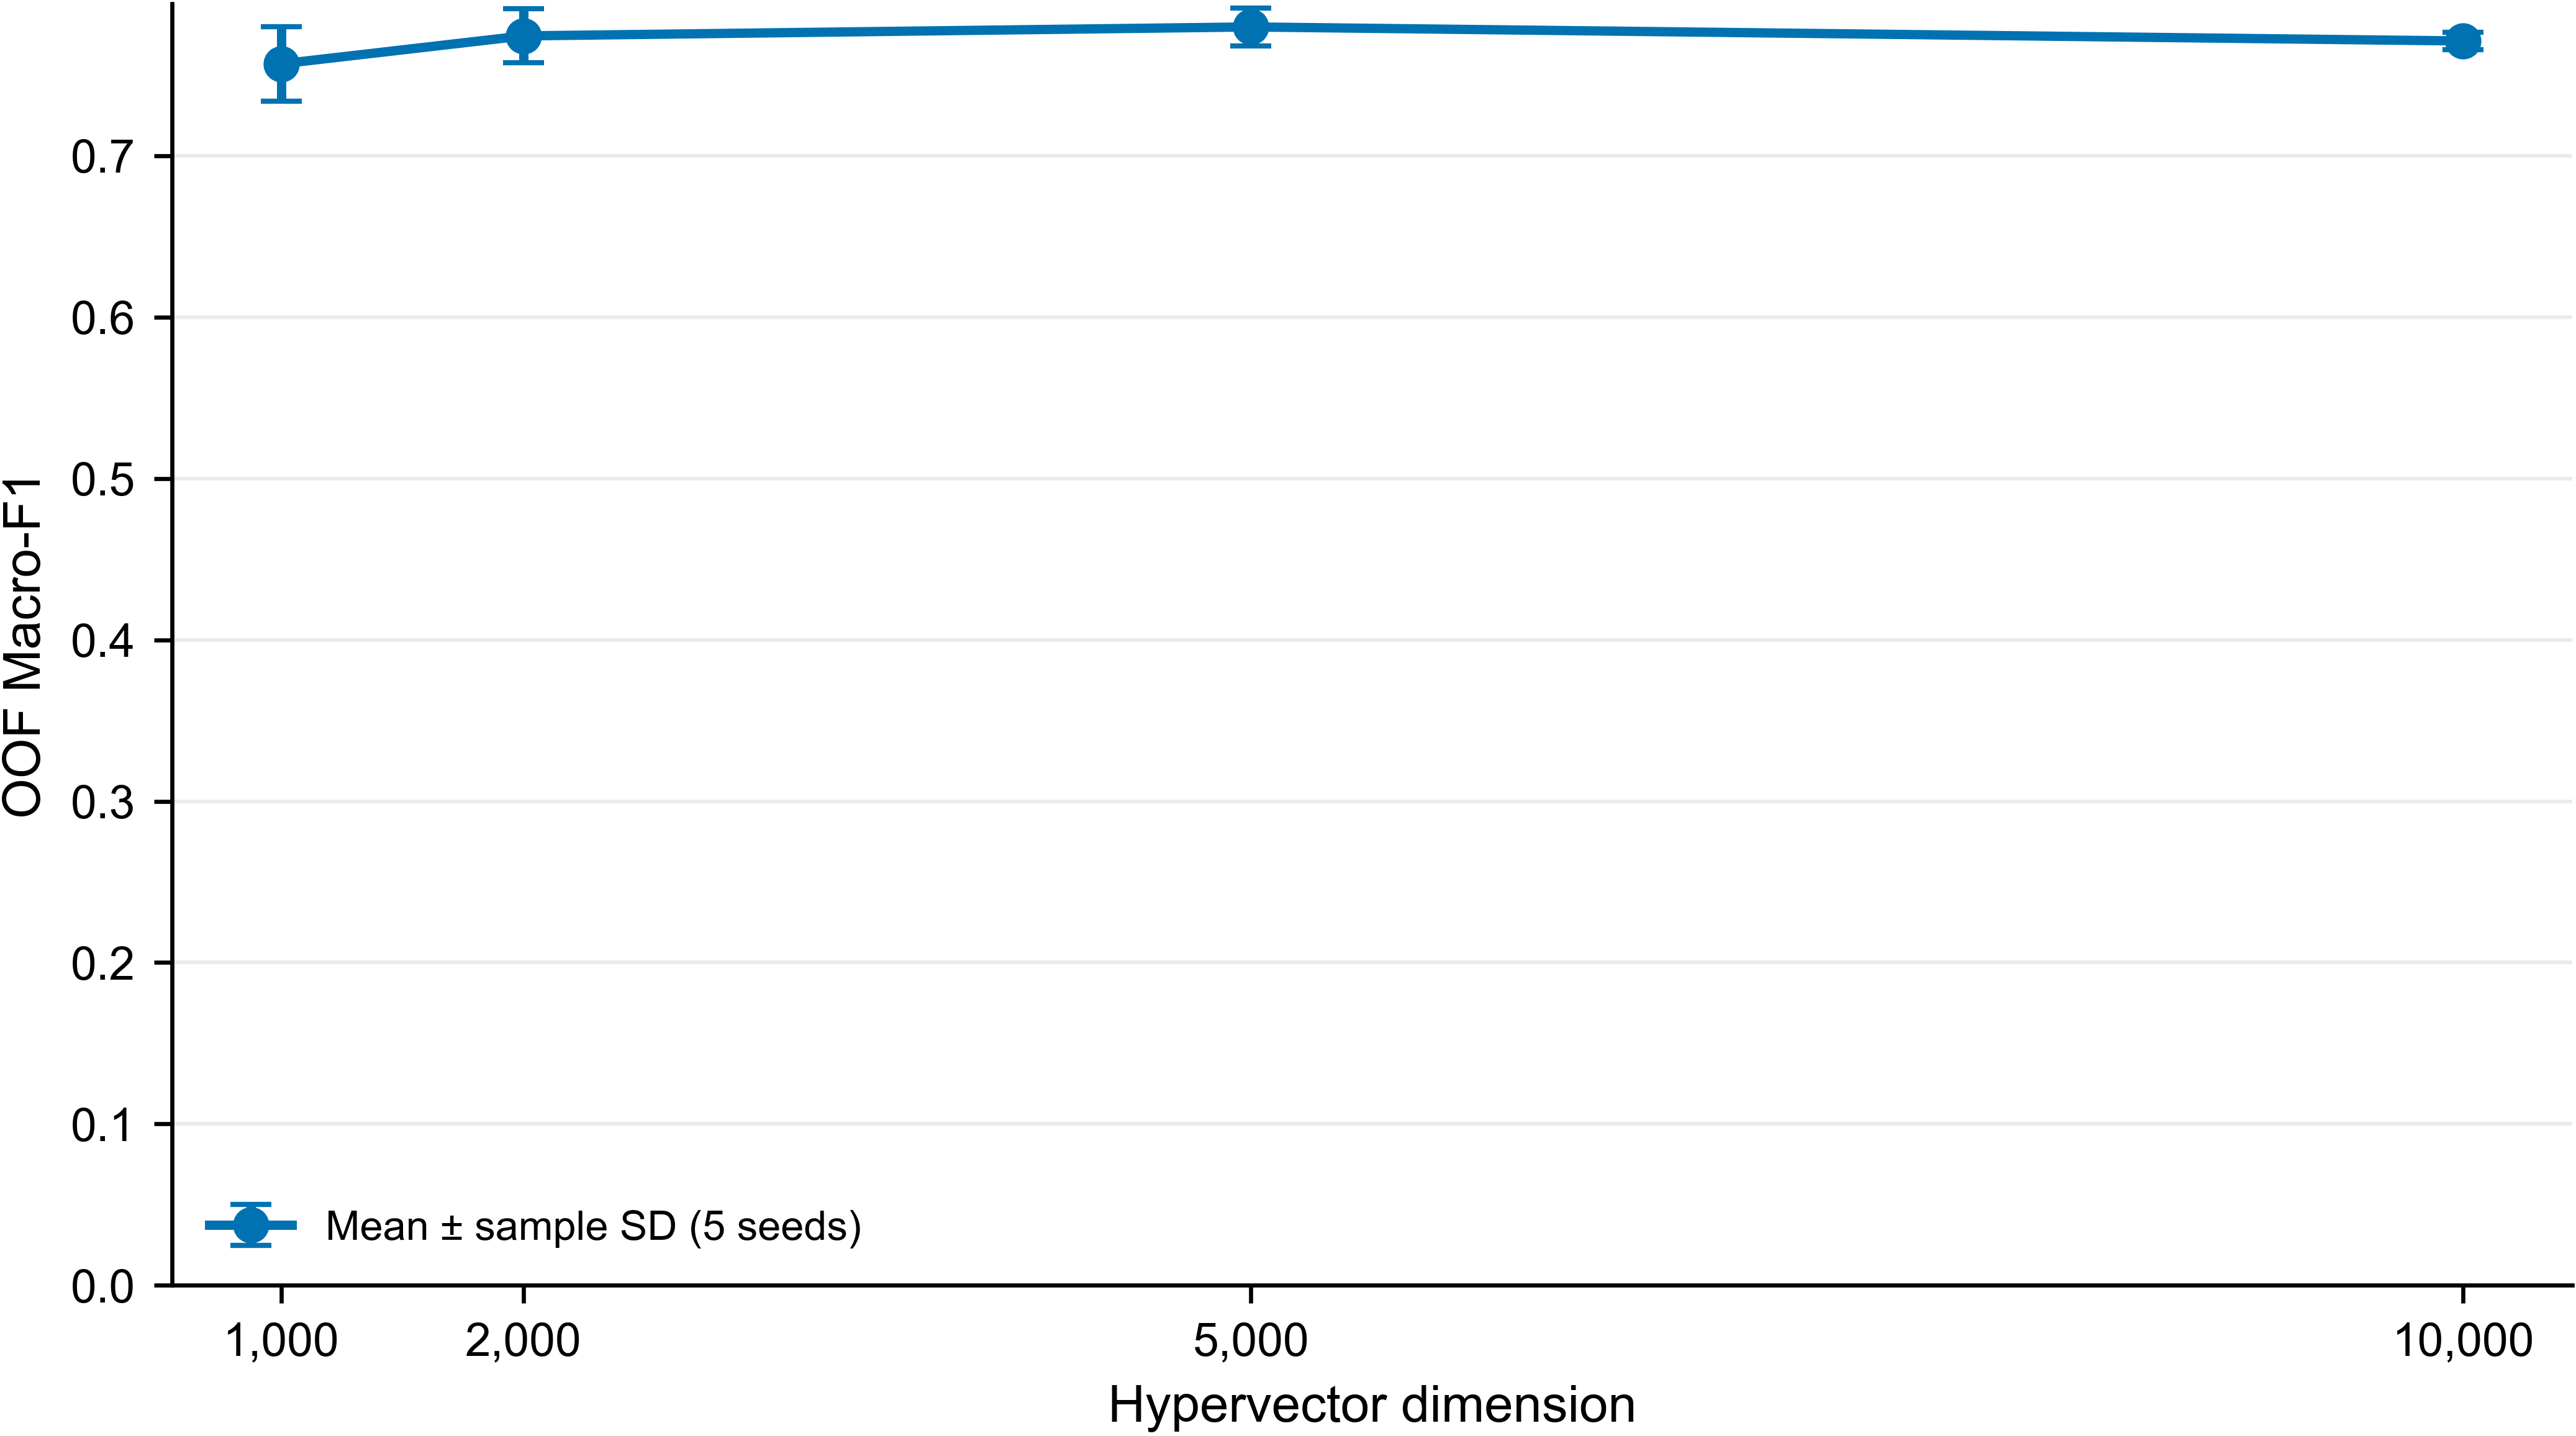

figures/phase05_classification_seed_stability.png


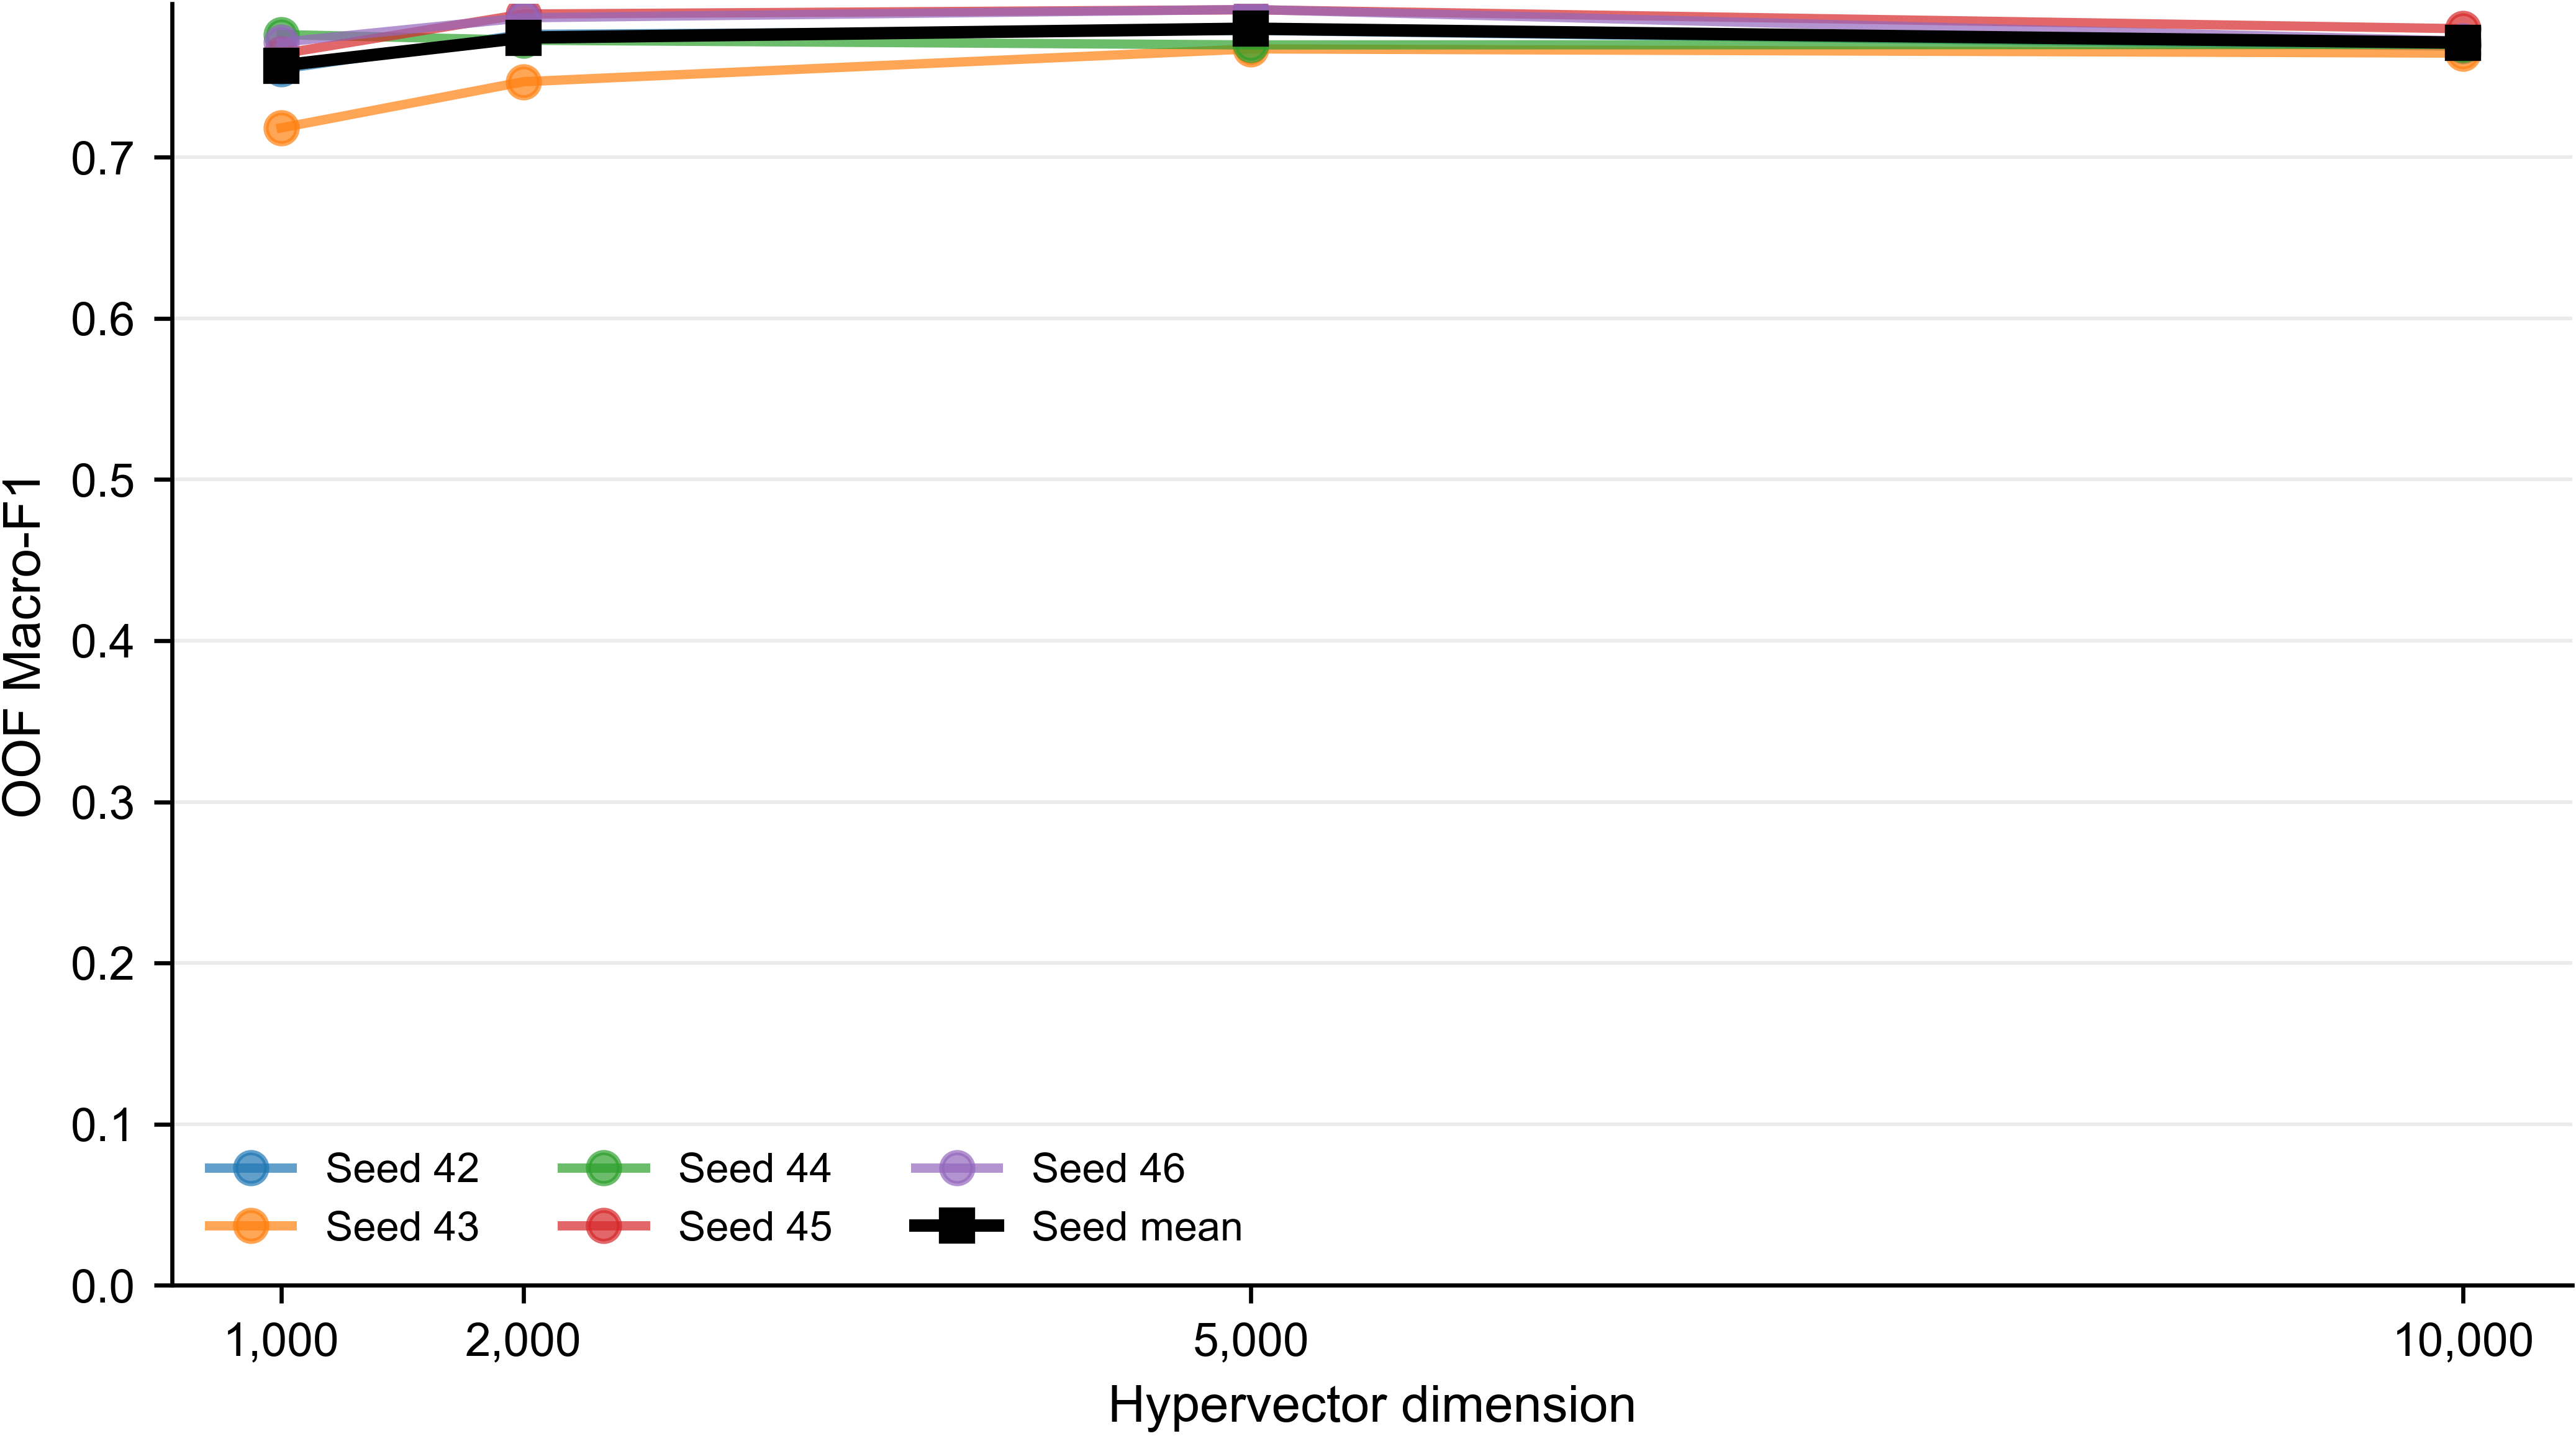

figures/phase05_similarity_regression_mae_vs_dimension.png


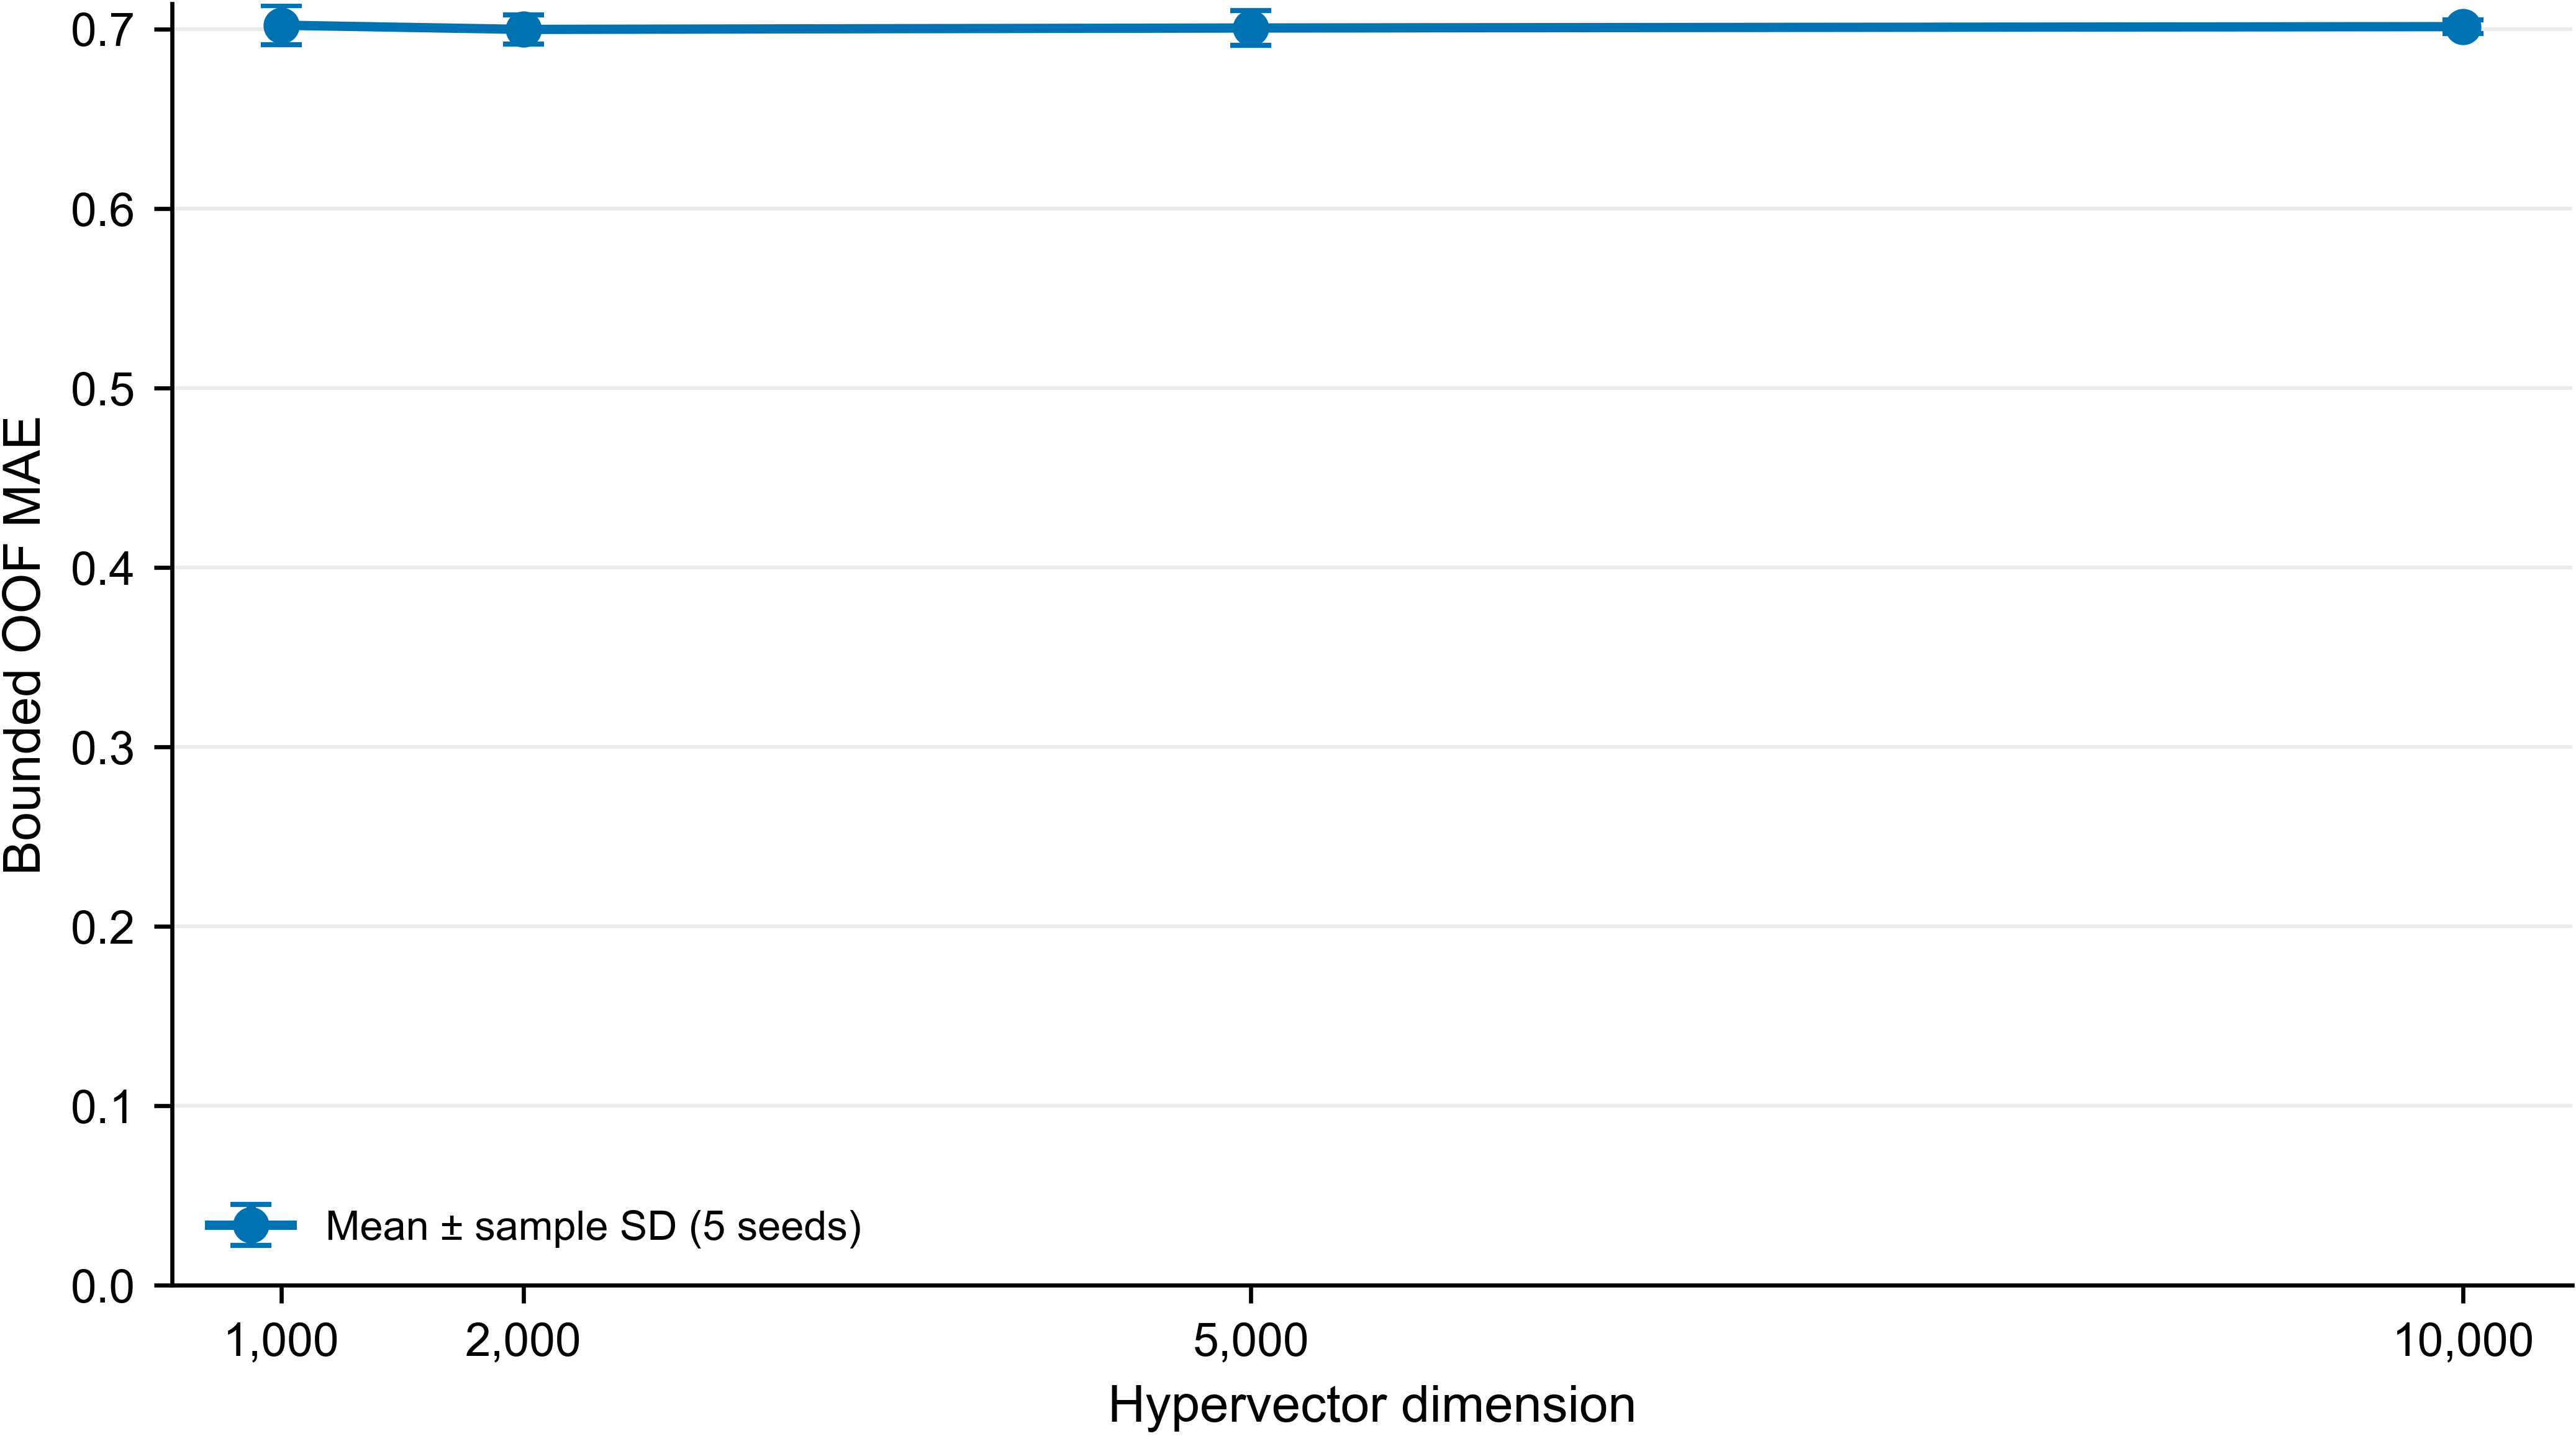

figures/phase05_ridge_regression_mae_vs_dimension.png


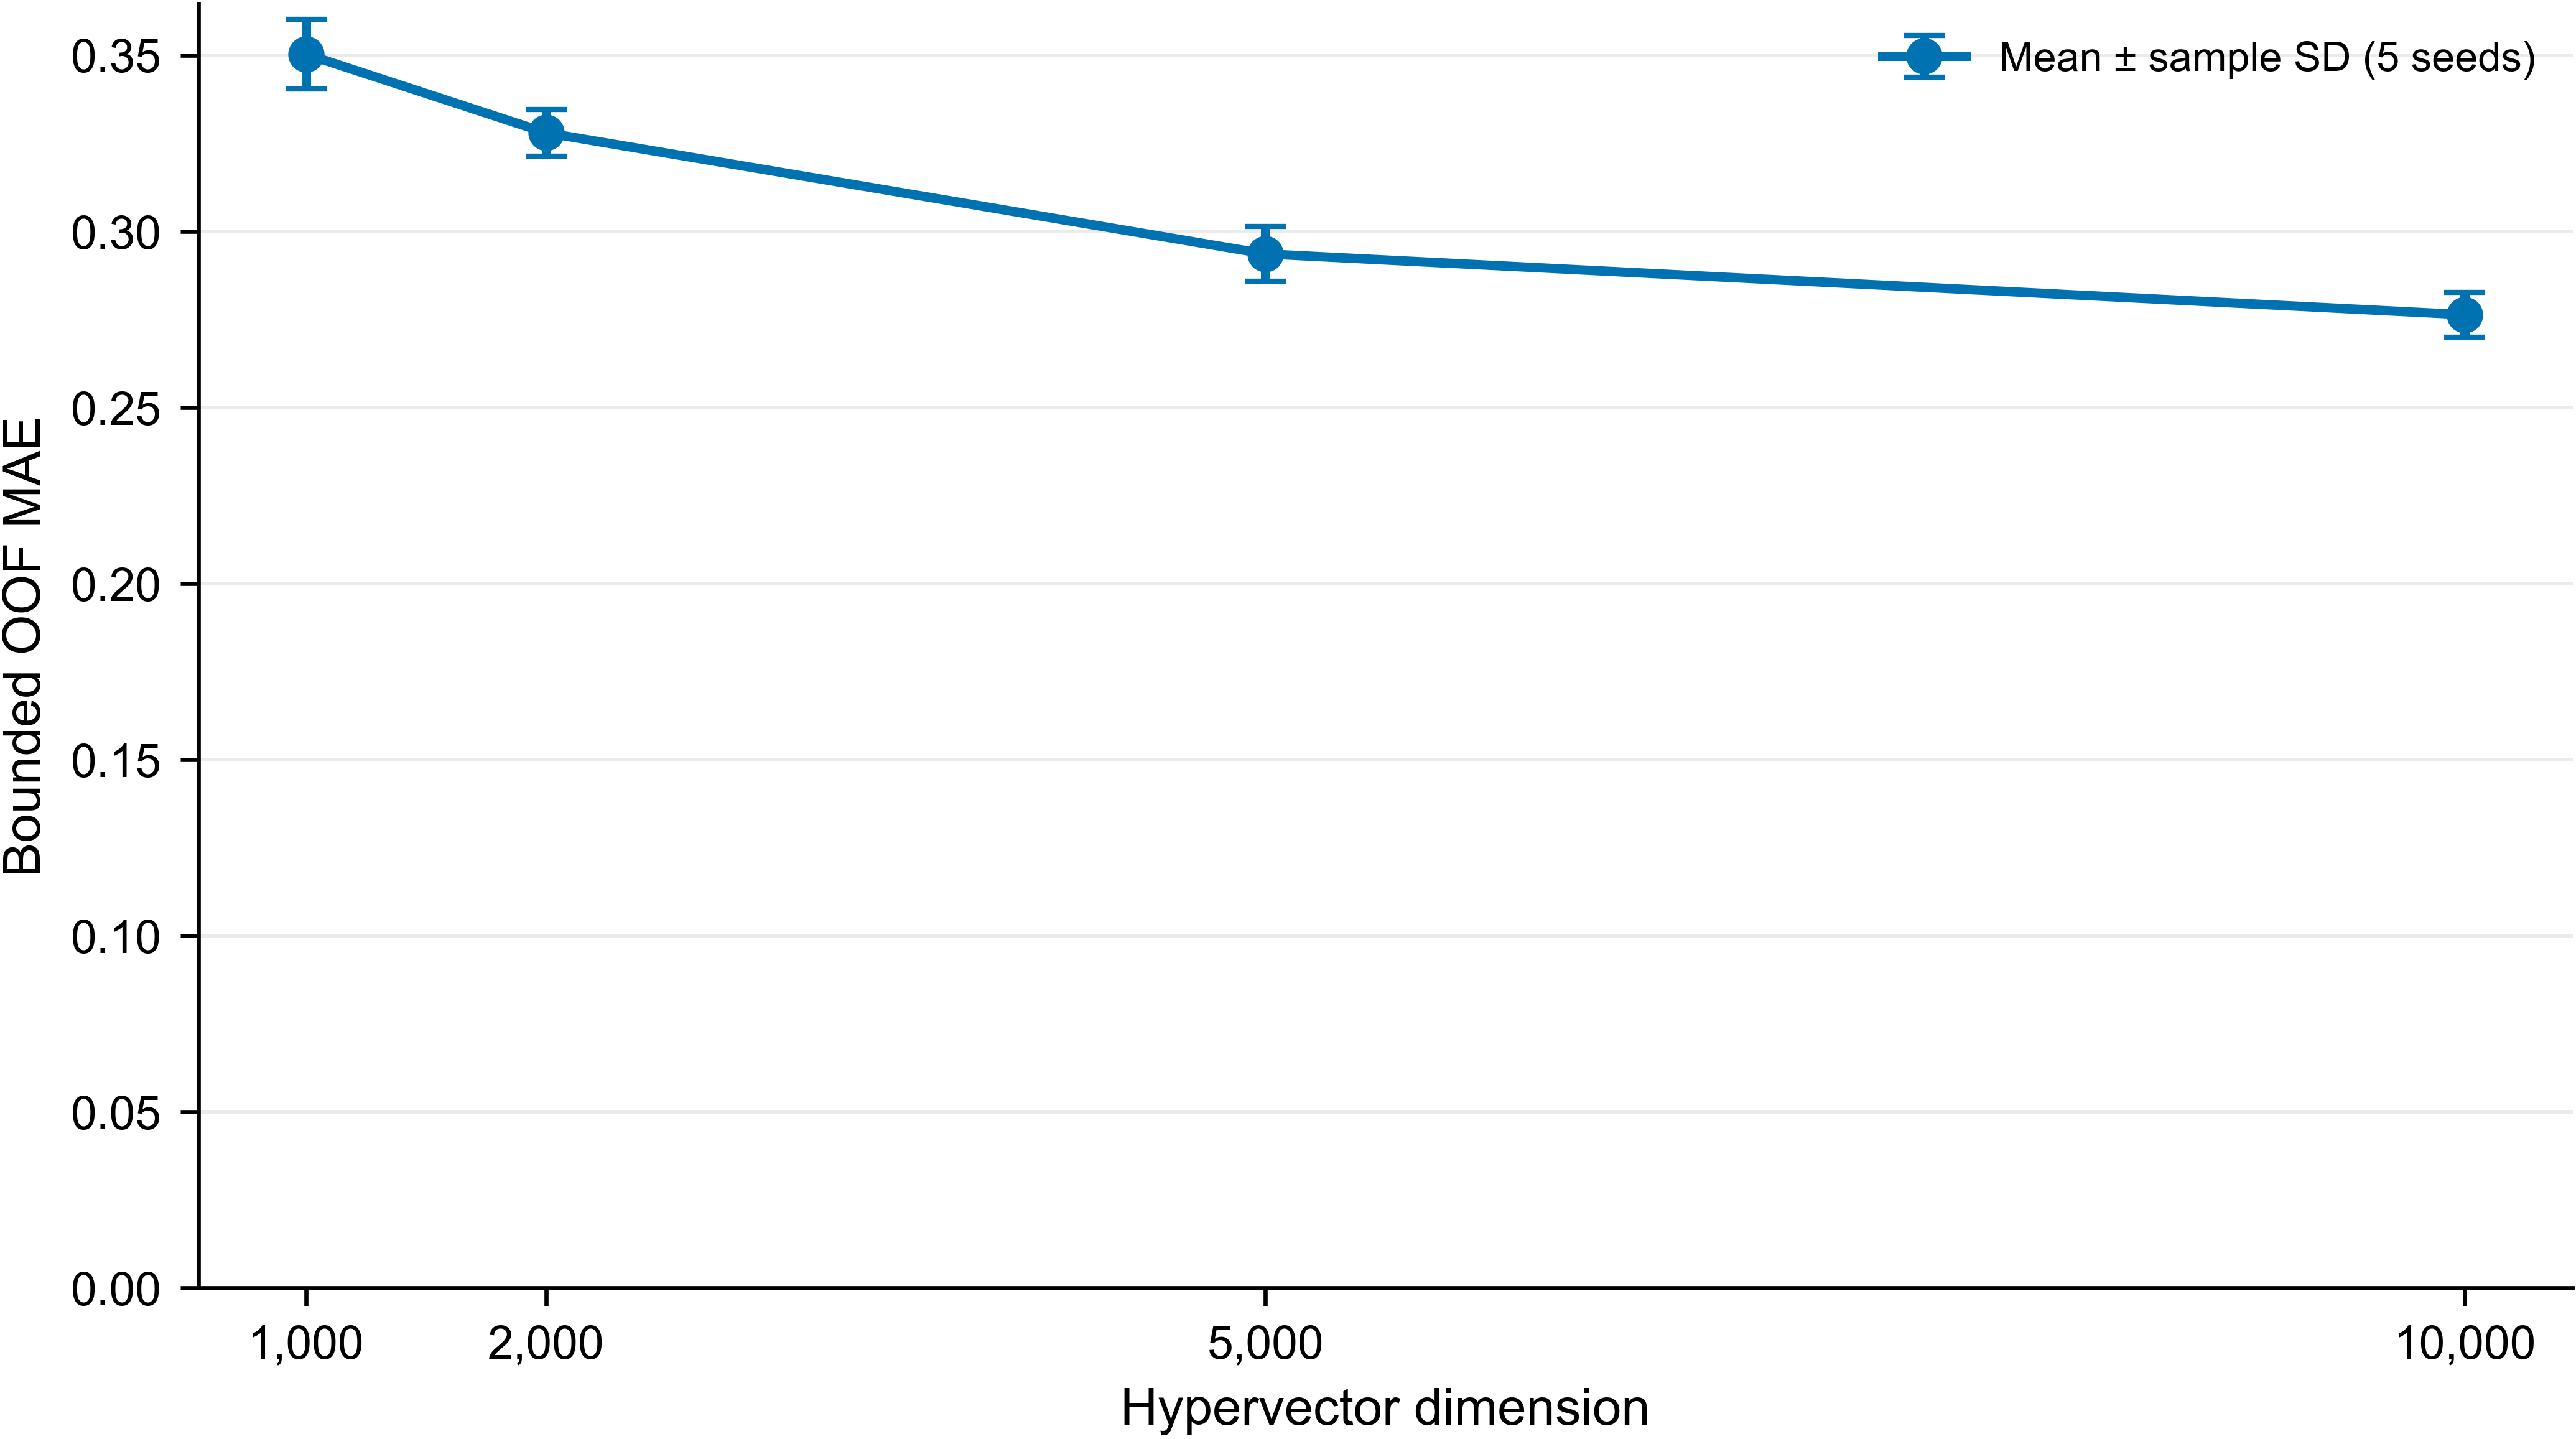

figures/phase05_regression_seed_stability.png


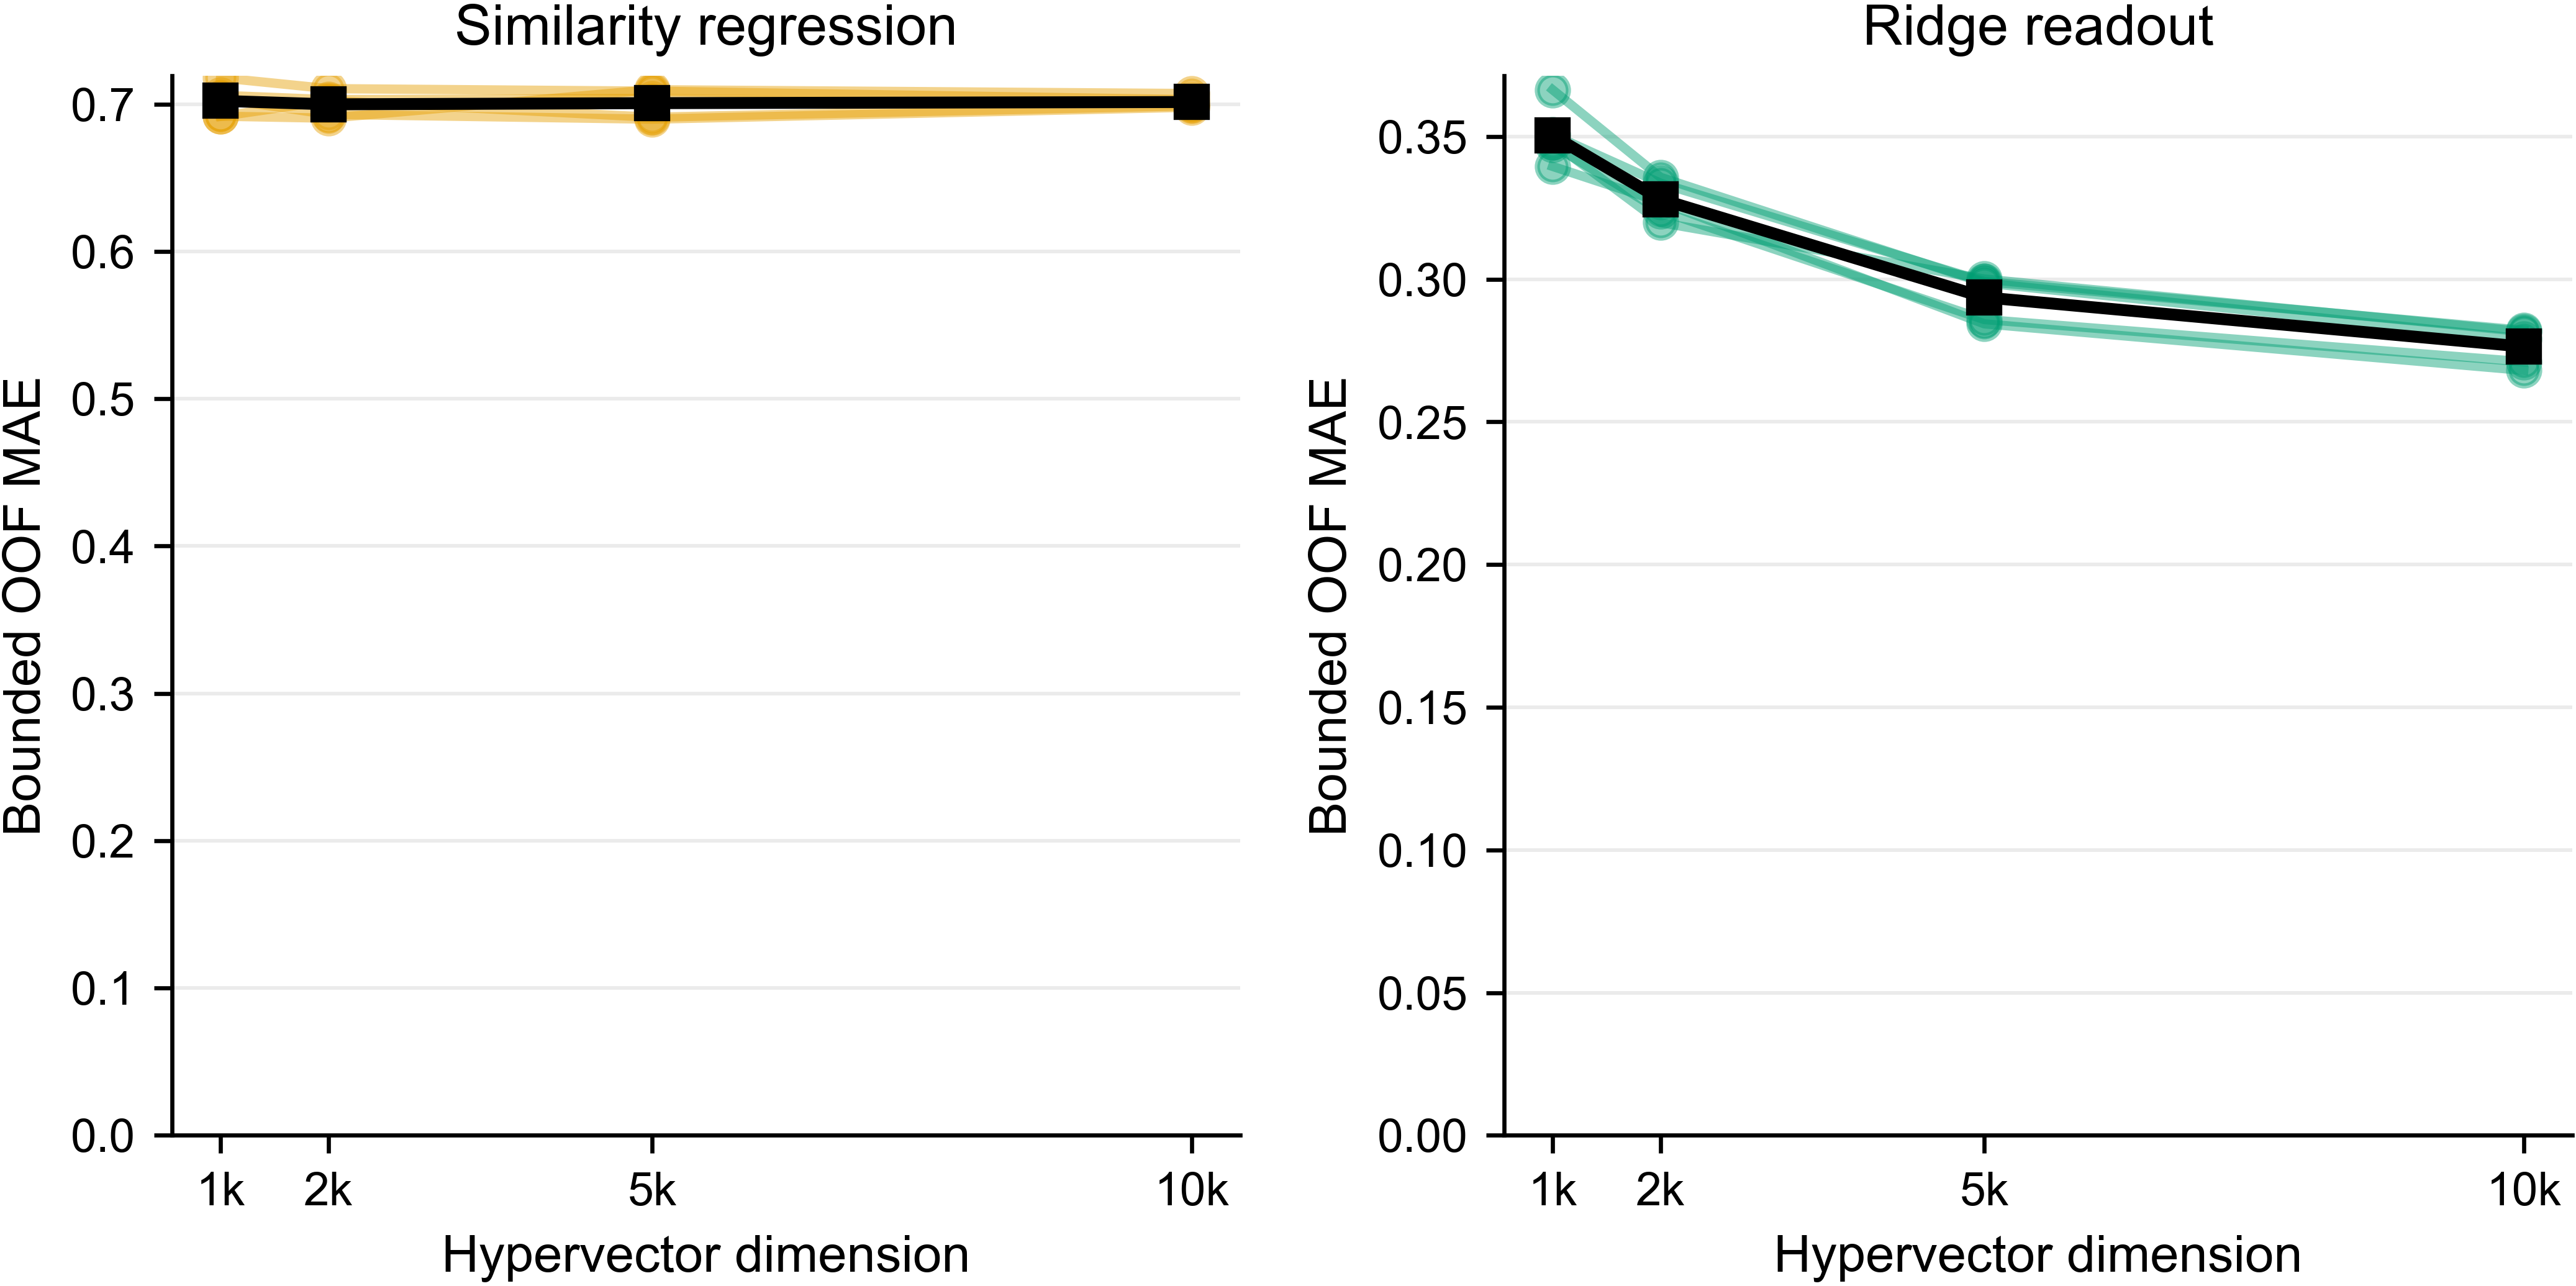

figures/phase05_accuracy_efficiency_tradeoff.png


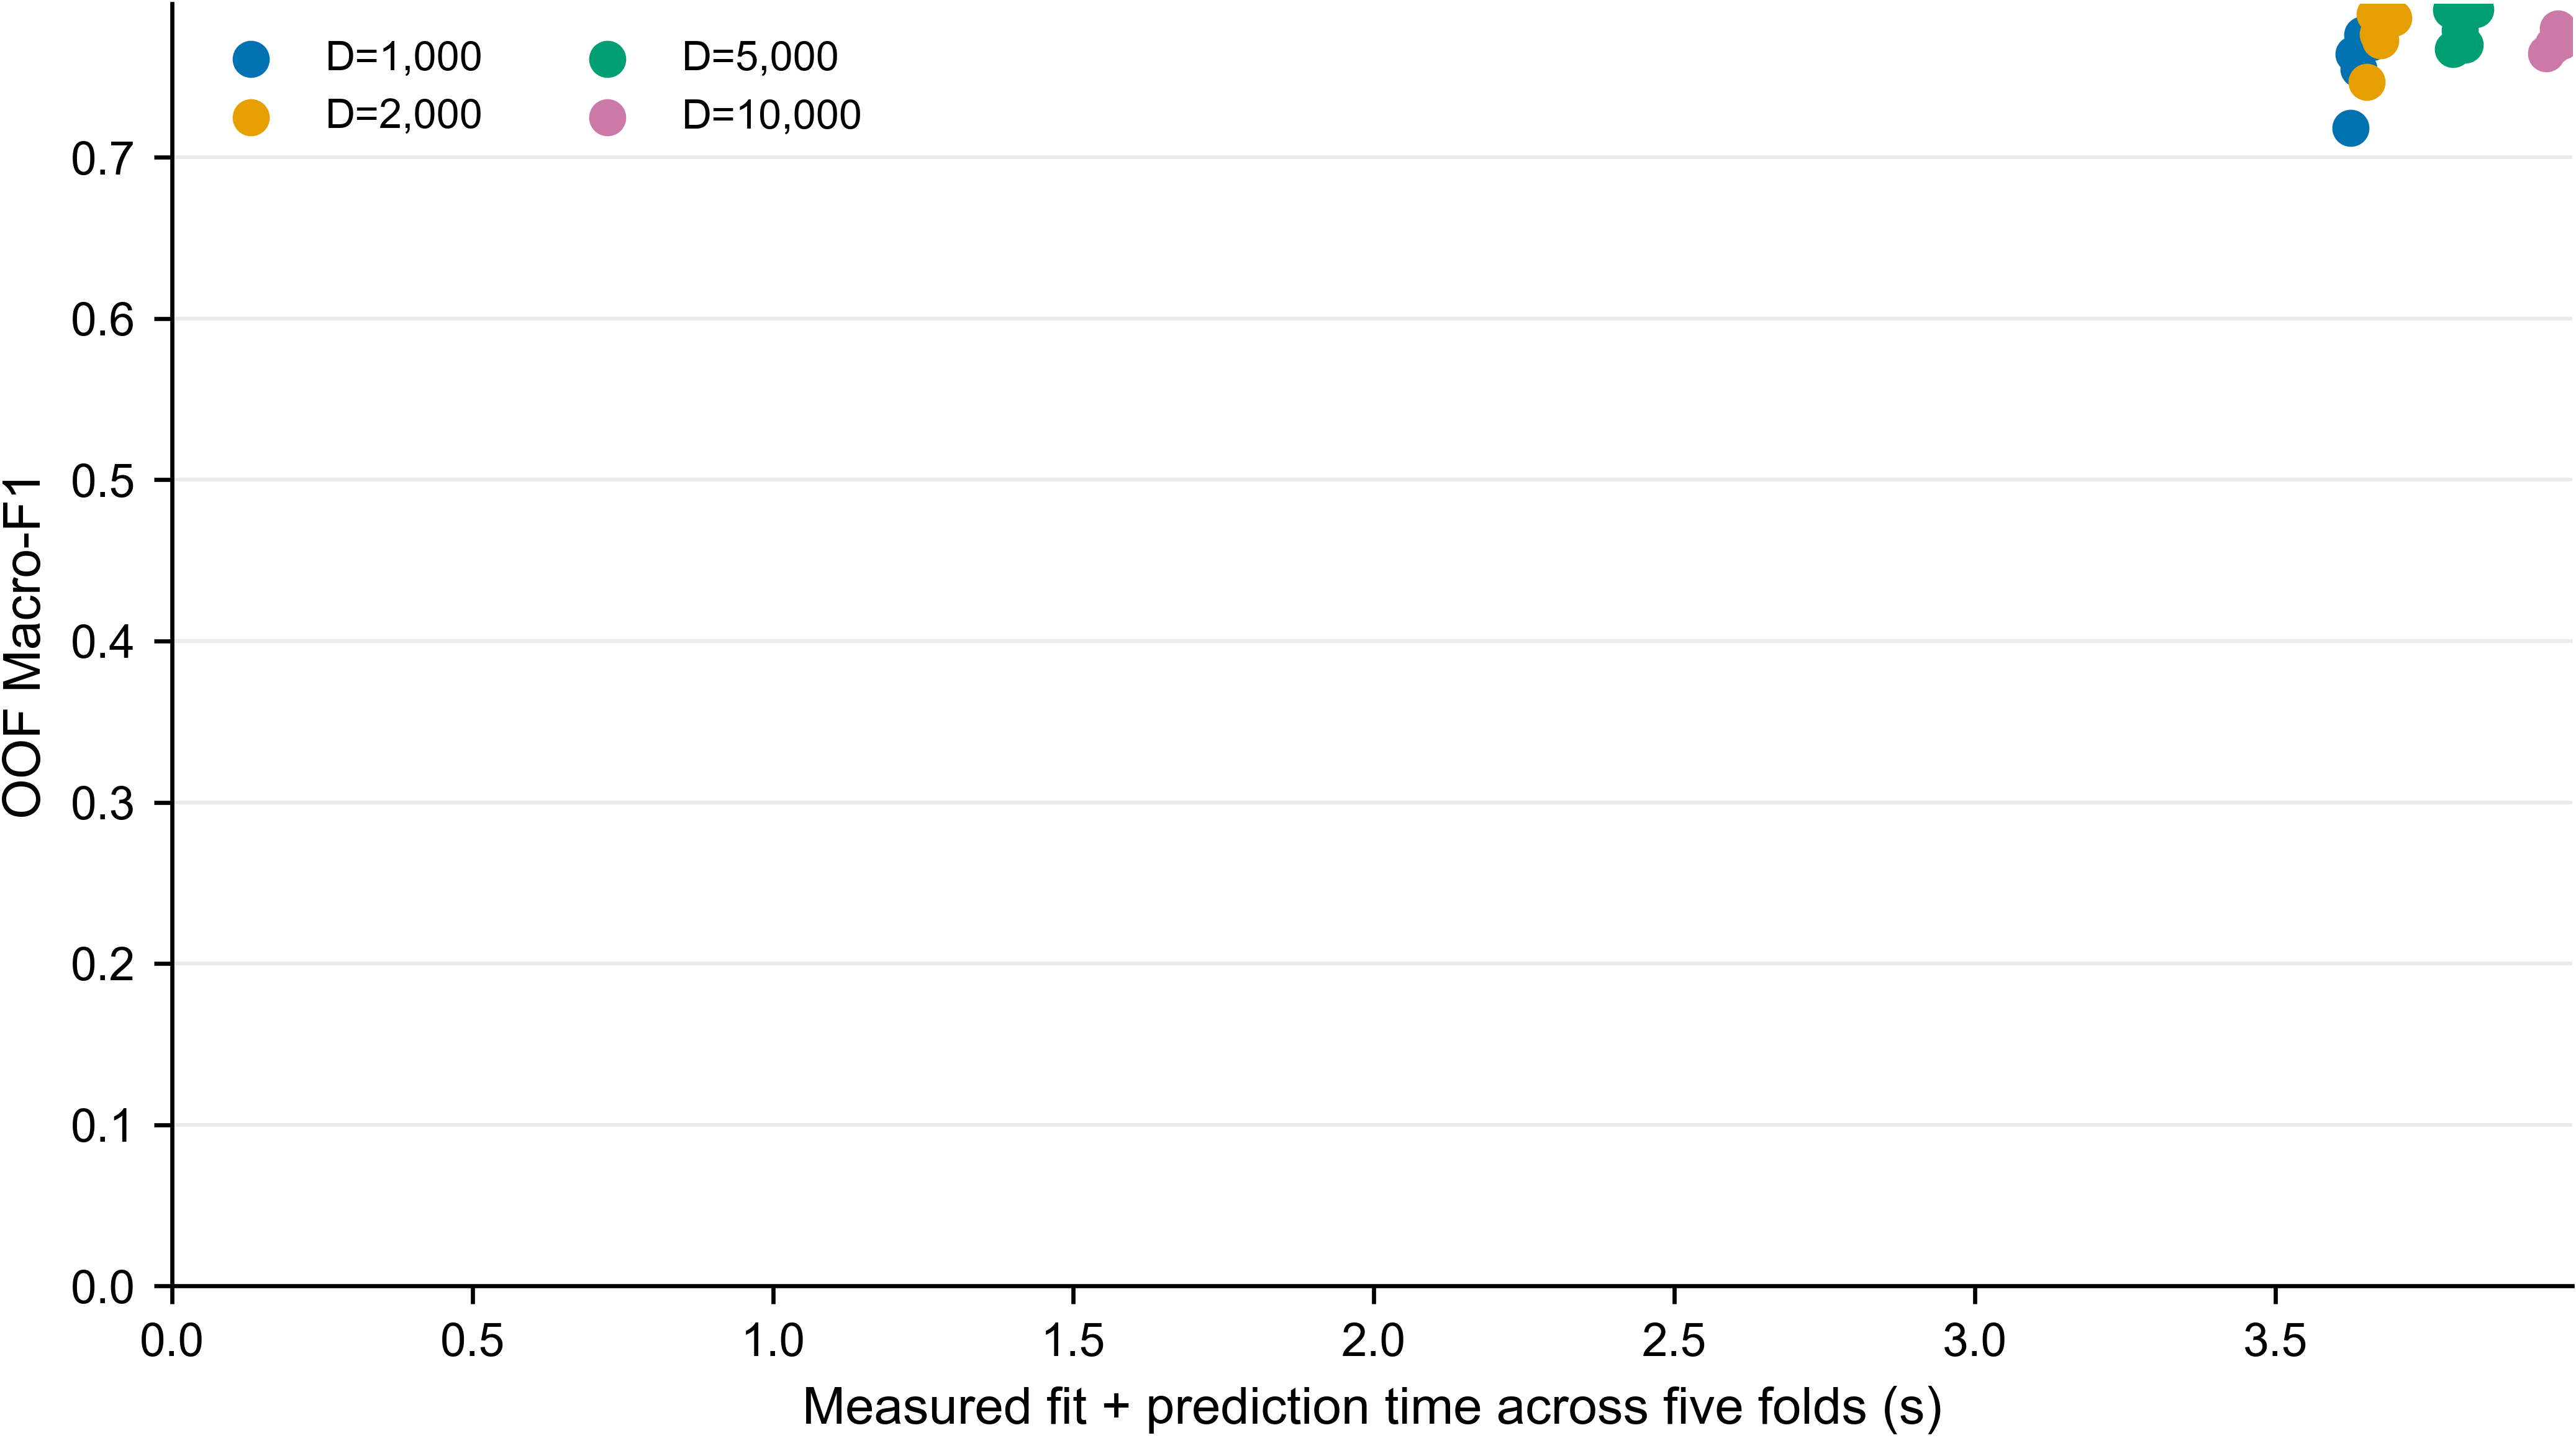

figures/phase05_classification_vs_traditional_baselines.png


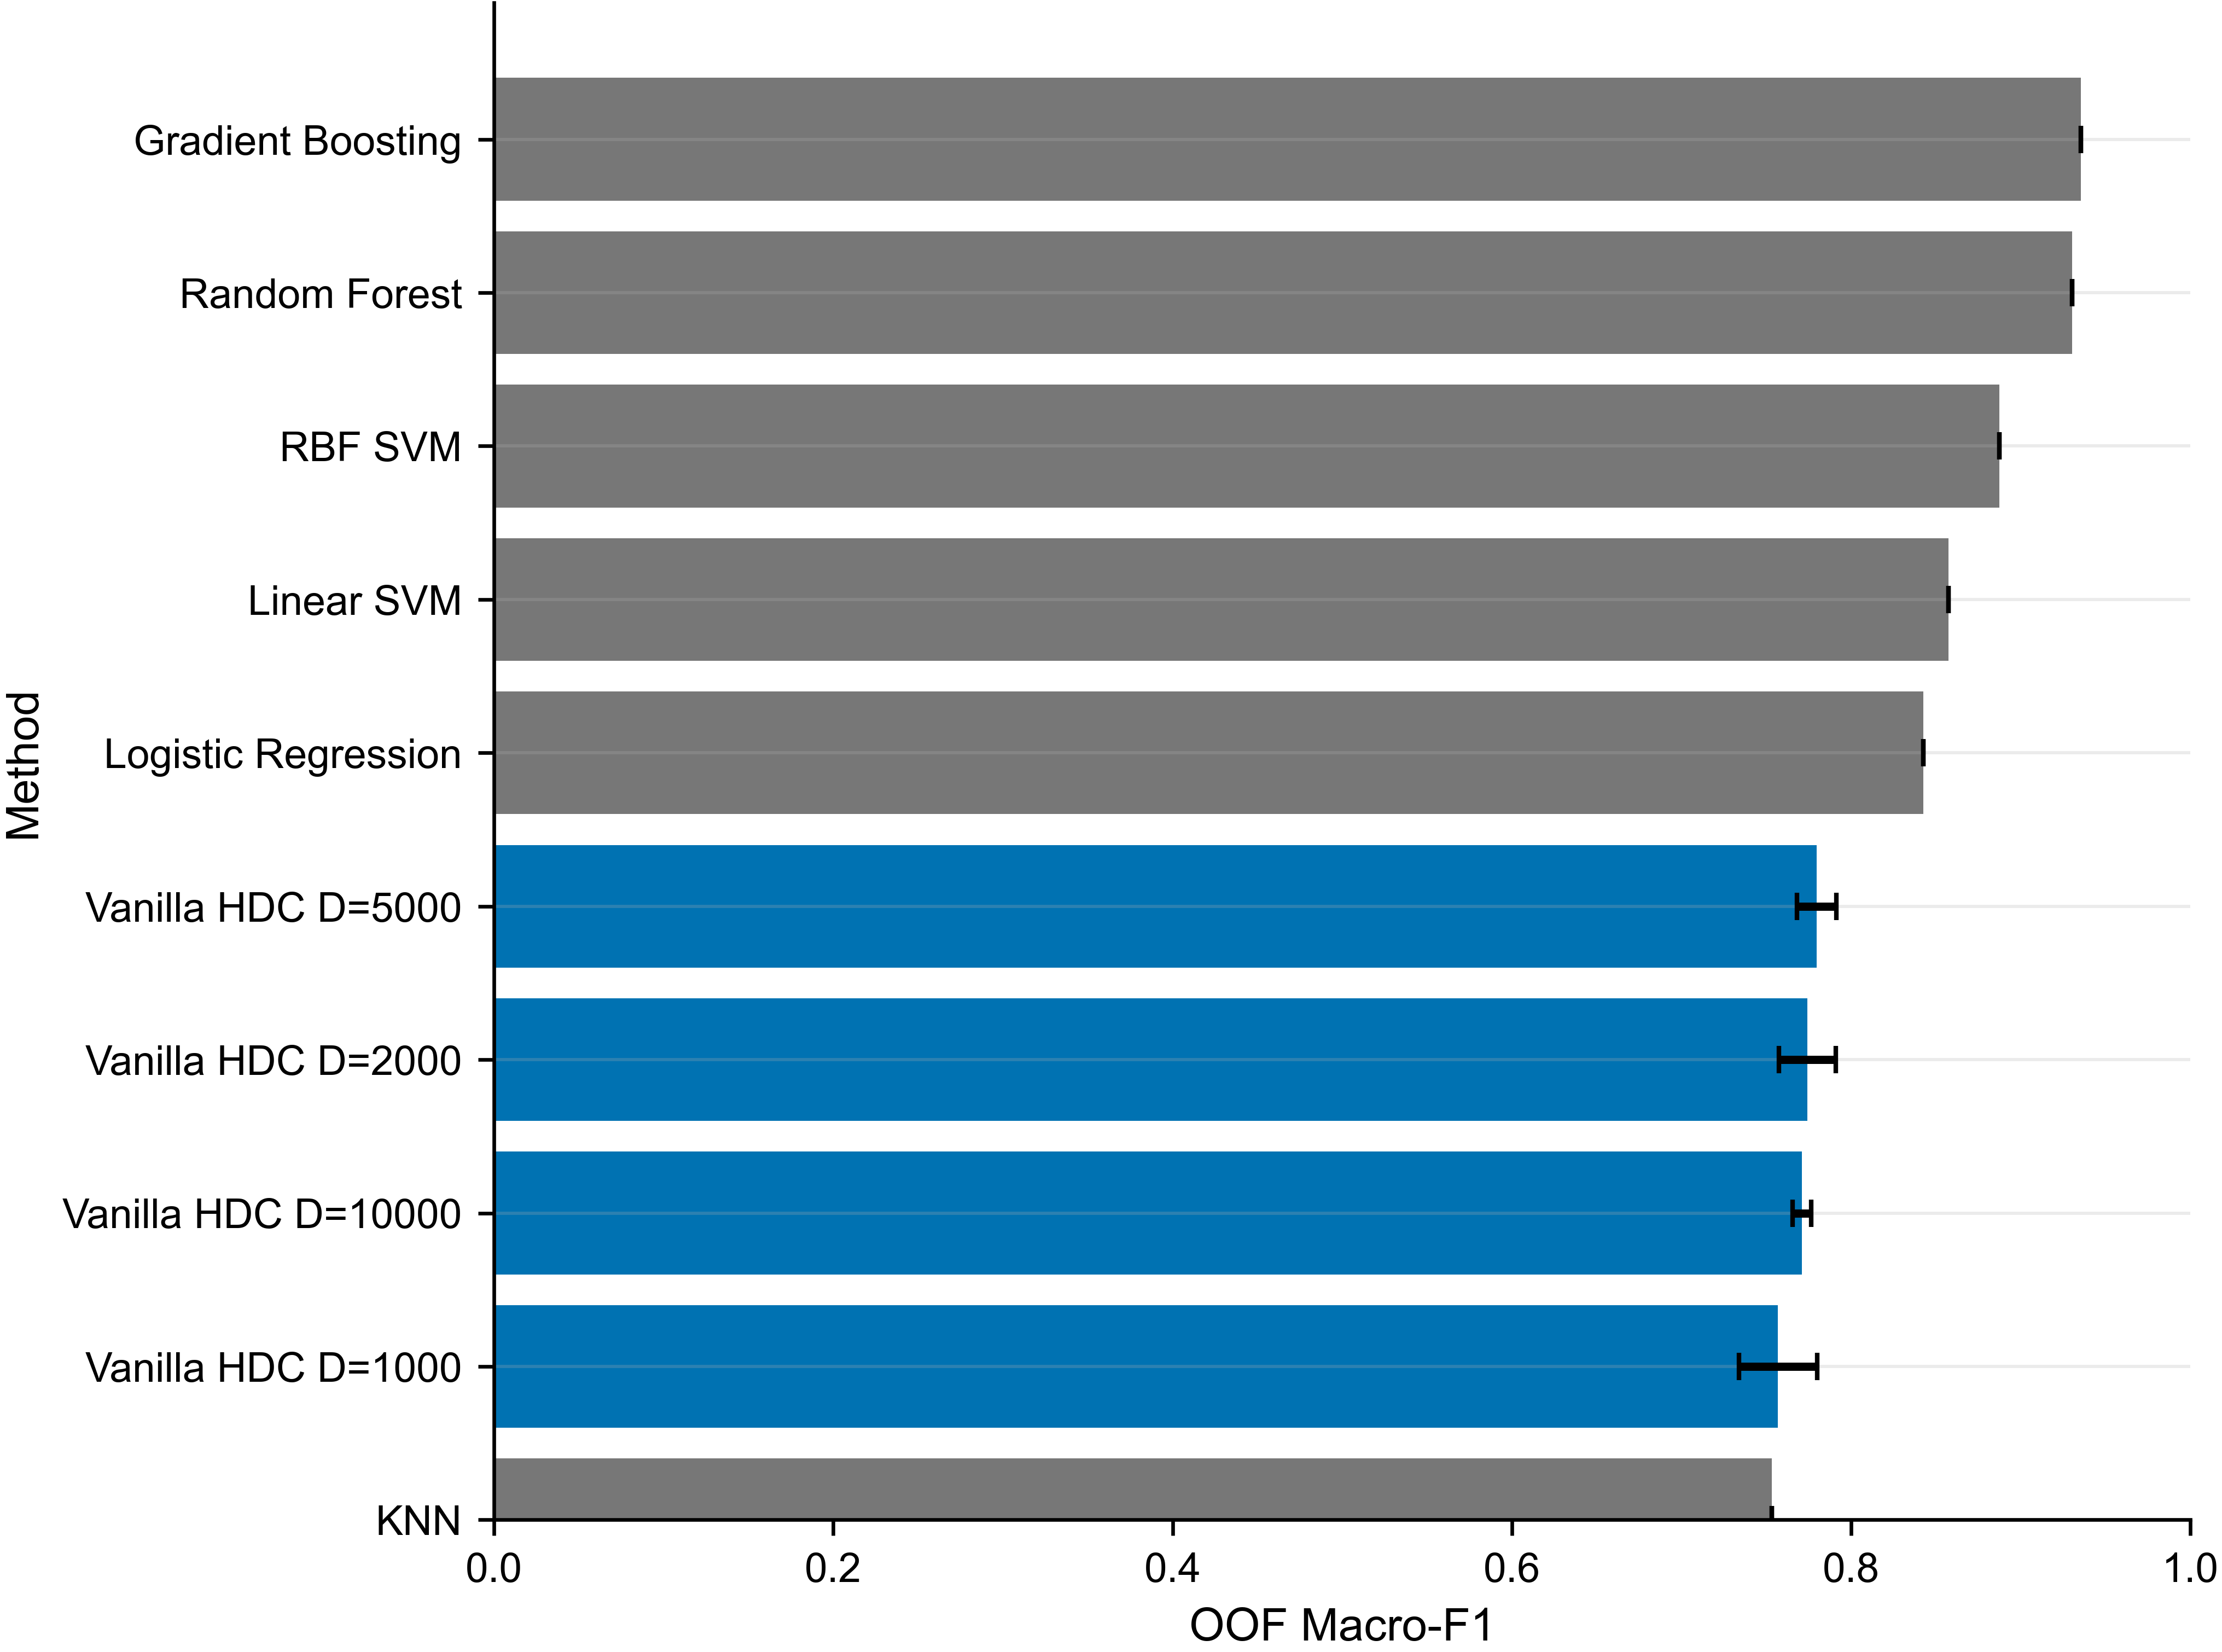

figures/phase05_regression_vs_traditional_baselines.png


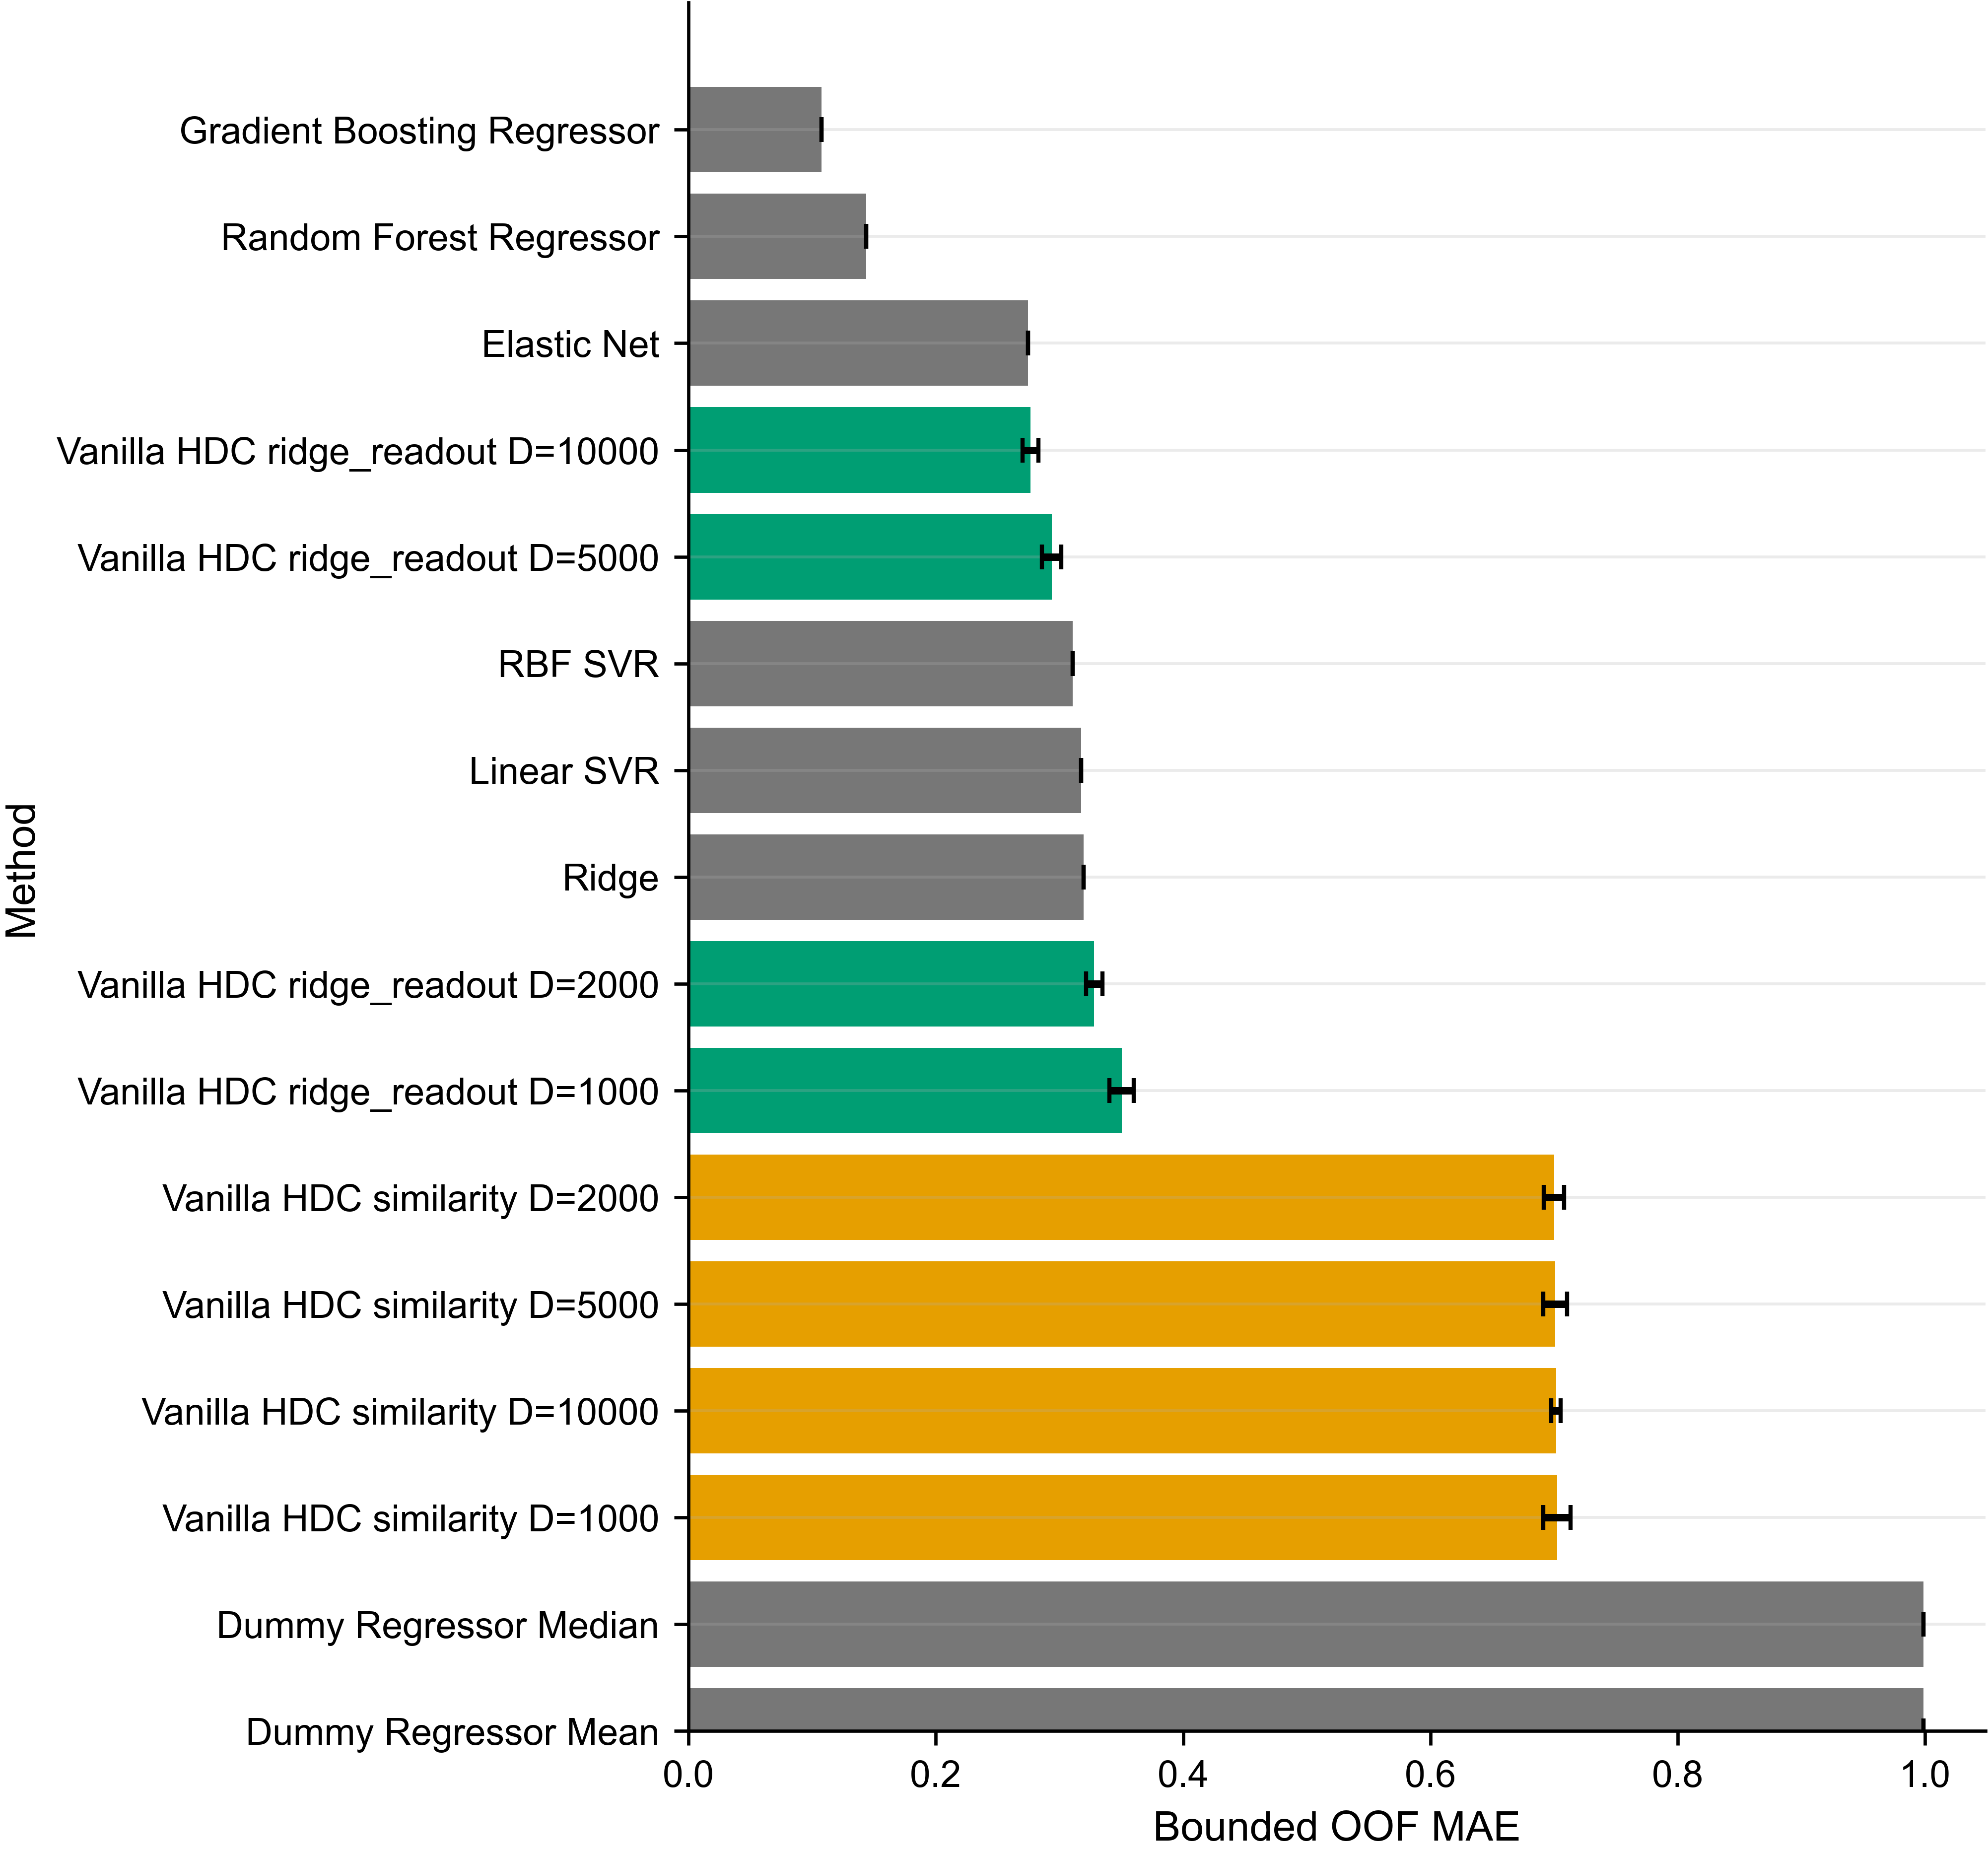

In [3]:
from IPython.display import Image, display
figure_paths = [
    'figures/phase05_classification_macro_f1_vs_dimension.png',
    'figures/phase05_classification_seed_stability.png',
    'figures/phase05_similarity_regression_mae_vs_dimension.png',
    'figures/phase05_ridge_regression_mae_vs_dimension.png',
    'figures/phase05_regression_seed_stability.png',
    'figures/phase05_accuracy_efficiency_tradeoff.png',
    'figures/phase05_classification_vs_traditional_baselines.png',
    'figures/phase05_regression_vs_traditional_baselines.png',
]
for rel in figure_paths:
    print(rel)
    display(Image(filename=str(phase / rel), width=980))


### Final audit and frozen status

The status below is read from the saved final audits, manifest, and freeze record.

In [1]:
from pathlib import Path
import json
from IPython.display import display

phase = Path.cwd()
def load_json(rel):
    return json.loads((phase / rel).read_text(encoding='utf-8'))

final_audits = {
    'artifact': load_json('audits/phase05_final_artifact_audit.json'),
    'reproducibility': load_json('audits/phase05_final_reproducibility_audit.json'),
    'upstream_freeze_integrity': load_json('audits/phase05_upstream_freeze_integrity_audit.json'),
}
final_manifest = load_json('manifests/phase05_final_artifact_manifest.json')
phase05_freeze = load_json('configs/phase05_freeze.json')
freeze_evidence = {key: phase05_freeze.get(key) for key in [
    'phase', 'phase_name', 'status', 'modeling_rows', 'subjects', 'primary_features',
    'outer_folds', 'dimensions', 'seeds', 'levels', 'feature_k', 'configurations',
    'final_confirmation_runs', 'canonical_configuration_selection',
    'ready_for_next_planned_phase',
]}
display({'final_audits': final_audits,
         'final_manifest_status': final_manifest.get('status'),
         'phase05_freeze': freeze_evidence})
assert all(item.get('result') == 'PASS' for item in final_audits.values())
assert phase05_freeze.get('status') == 'FROZEN'
print('PHASE 05 STATUS: FROZEN; READY TO PROCEED TO NEXT PLANNED PHASE: YES')


{'final_audits': {'artifact': {'phase': '05',
   'audit': 'final_artifact',
   'timestamp_utc': '2026-08-20T05:34:11.359065+00:00',
   'final_manifest_sha256': '854a547644ec7708527aac08a6cfd214c562961166ec7328c27f7968d09e6991',
   'artifacts_verified': 389,
   'checks': {'primary_data_checksum_pass': True,
    'frozen_fold_checksum_pass': True,
    'quick_screen_audit_pass': True,
    'final_confirmation_5_of_5_folds': True,
    'final_confirmation_100_of_100_configs': True,
    'oof_coverage_pass': True,
    'oof_alignment_pass': True,
    'leakage_audit_pass': True,
    'reproducibility_audit_pass': True,
    'upstream_freeze_integrity_pass': True,
    'notebook_persistence_pass': True,
    'final_report_saved': True,
    'final_manifest_saved': True,
    'manifest_parse_pass': True,
    'all_manifest_artifacts_exist': True,
    'all_manifest_sizes_match': True,
    'all_manifest_hashes_match': True,
    'manifest_self_hash_excluded': True,
    'freeze_file_excluded': True},
   'resu

PHASE 05 STATUS: FROZEN; READY TO PROCEED TO NEXT PLANNED PHASE: YES


## No-Retraining Compliance Completion

This amendment derives diagnostics from the unchanged frozen OOF table and benchmarks read-only inference from saved fitted artifacts. It does not refit a model, replace a prediction, select a canonical configuration, or start Phase 06.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

phase = Path.cwd()
def load_amendment_json(rel):
    return json.loads((phase / rel).read_text(encoding='utf-8'))

diagnostic_audit = load_amendment_json('audits/phase05_no_retraining_diagnostic_completion_audit.json')
class_diag = pd.read_csv(phase / 'results/summaries/vanilla_hdc_classification_diagnostics_by_config.csv')
similarity_diag = pd.read_csv(phase / 'results/summaries/vanilla_hdc_similarity_regression_diagnostics_by_config.csv')
ridge_diag = pd.read_csv(phase / 'results/summaries/vanilla_hdc_ridge_regression_diagnostics_by_config.csv')
cross_task = pd.read_csv(phase / 'results/summaries/vanilla_hdc_cross_task_consistency_by_config.csv')
display({'diagnostic_audit': diagnostic_audit})
for label, frame in [('classification', class_diag), ('similarity', similarity_diag),
                     ('ridge', ridge_diag), ('cross_task', cross_task)]:
    print(f'{label}: rows={len(frame)}, columns={len(frame.columns)}')
    display(frame)
assert diagnostic_audit.get('result') == 'PASS'
assert diagnostic_audit.get('model_fitting_executed') is False


{'diagnostic_audit': {'phase': '05',
  'audit': 'no_retraining_diagnostic_completion',
  'created_utc': '2026-08-20T05:54:19.292995+00:00',
  'source_oof': 'results\\oof\\vanilla_hdc_final_confirmation_oof_long.csv',
  'source_oof_sha256_before': 'bbc3d2044e9e1e527eed7e0f40d41ba569033073cb437e6d9aec3ccce1d837ad',
  'source_oof_sha256_after': 'bbc3d2044e9e1e527eed7e0f40d41ba569033073cb437e6d9aec3ccce1d837ad',
  'source_oof_unchanged': True,
  'rows': 8380,
  'configs': 20,
  'probability_row_sum_max_abs_error': 3.3306690738754696e-16,
  'similarity_prediction_max_abs_error': 2.6645352591003757e-15,
  'classification_prediction_mismatches': 0,
  'model_fitting_executed': False,
  'prediction_artifact_replaced': False,
  'result': 'PASS'}}

classification: rows=20, columns=11


,dimension,seed,oof_rows,recall_class_0,recall_class_1,recall_class_2,recall_class_3,similarity_margin_mean,similarity_margin_std,similarity_margin_min,similarity_margin_max
0,1000,42,419,0.711538,0.650943,0.682692,0.990476,0.021318,0.019104,5.567074e-05,0.084502
1,1000,43,419,0.634615,0.660377,0.605769,0.990476,0.019781,0.019184,2.622604e-06,0.088018
2,1000,44,419,0.778846,0.707547,0.644231,0.990476,0.019965,0.018080,3.272295e-05,0.090381
3,1000,45,419,0.711538,0.698113,0.673077,0.990476,0.019717,0.018475,3.182888e-05,0.097069
4,1000,46,419,0.711538,0.726415,0.663462,1.000000,0.018235,0.015996,2.312660e-05,0.089071
5,2000,42,419,0.740385,0.669811,0.711538,1.000000,0.019811,0.018119,1.442432e-05,0.086135
6,2000,43,419,0.701923,0.669811,0.634615,1.000000,0.019848,0.018817,4.756451e-05,0.088117
7,2000,44,419,0.730769,0.707547,0.673077,0.990476,0.020459,0.018176,1.138449e-04,0.085425
8,2000,45,419,0.750000,0.716981,0.701923,1.000000,0.019688,0.018742,1.000166e-04,0.096587
9,2000,46,419,0.740385,0.735849,0.692308,0.990476,0.020007,0.018377,2.837181e-05,0.086907


similarity: rows=20, columns=30


,dimension,seed,oof_rows,prediction_mean,prediction_std,prediction_min,prediction_max,prediction_range,mean_abs_distance_from_midpoint_2_5,rounded_unique_levels,...,true_level_2_prediction_mean,true_level_2_prediction_std,true_level_3_rows,true_level_3_mae,true_level_3_prediction_mean,true_level_3_prediction_std,true_level_4_rows,true_level_4_mae,true_level_4_prediction_mean,true_level_4_prediction_std
0,1000,42,419,2.483945,0.447443,1.734632,3.548500,1.813867,0.393590,3,...,2.214600,0.243373,104,0.536177,2.477270,0.231841,105,0.885095,3.114905,0.155851
1,1000,43,419,2.487689,0.459589,1.708177,3.574912,1.866735,0.400671,3,...,2.227401,0.279304,104,0.555933,2.479735,0.296424,105,0.895049,3.104951,0.198852
2,1000,44,419,2.483531,0.458109,1.773664,3.615263,1.841599,0.399174,3,...,2.223483,0.276590,104,0.522888,2.504276,0.263585,105,0.906555,3.093445,0.202533
3,1000,45,419,2.472416,0.431185,1.753038,3.634950,1.881912,0.379149,3,...,2.222339,0.259652,104,0.556923,2.463745,0.258208,105,0.944891,3.055109,0.191626
4,1000,46,419,2.478290,0.422211,1.840966,3.623535,1.782568,0.372312,3,...,2.224945,0.244564,104,0.510193,2.512618,0.252677,105,0.952723,3.047277,0.156632
5,2000,42,419,2.477628,0.433618,1.791372,3.544070,1.752698,0.383990,3,...,2.220645,0.240343,104,0.545863,2.465939,0.232893,105,0.910881,3.089119,0.148496
6,2000,43,419,2.489002,0.457171,1.723786,3.555105,1.831319,0.398546,3,...,2.228484,0.275856,104,0.549373,2.484122,0.285097,105,0.893802,3.106198,0.186321
7,2000,44,419,2.482427,0.454660,1.796115,3.580204,1.784089,0.399607,3,...,2.213898,0.264409,104,0.533640,2.488038,0.257852,105,0.892998,3.107002,0.175026
8,2000,45,419,2.474501,0.436256,1.744877,3.606290,1.861413,0.385267,3,...,2.220009,0.257410,104,0.553445,2.465950,0.258366,105,0.928712,3.071288,0.174746
9,2000,46,419,2.480605,0.450201,1.785437,3.568492,1.783054,0.396706,3,...,2.214685,0.252140,104,0.540517,2.488881,0.269046,105,0.900024,3.099976,0.171280


ridge: rows=20, columns=30


,dimension,seed,oof_rows,prediction_mean,prediction_std,prediction_min,prediction_max,prediction_range,mean_abs_distance_from_midpoint_2_5,rounded_unique_levels,...,true_level_2_prediction_mean,true_level_2_prediction_std,true_level_3_rows,true_level_3_mae,true_level_3_prediction_mean,true_level_3_prediction_std,true_level_4_rows,true_level_4_mae,true_level_4_prediction_mean,true_level_4_prediction_std
0,1000,42,419,2.497867,0.967350,1.0,4.0,3.0,0.855470,4,...,1.943276,0.474844,104,0.298537,2.883923,0.381890,105,0.270185,3.729815,0.309363
1,1000,43,419,2.511788,0.946509,1.0,4.0,3.0,0.822736,4,...,1.978690,0.451893,104,0.313392,2.836204,0.374485,105,0.253073,3.746927,0.315933
2,1000,44,419,2.501047,0.953792,1.0,4.0,3.0,0.842512,4,...,1.944613,0.462502,104,0.274962,2.898189,0.357035,105,0.297184,3.702816,0.330329
3,1000,45,419,2.492223,0.931655,1.0,4.0,3.0,0.816416,4,...,1.966450,0.439014,104,0.328318,2.842200,0.418888,105,0.324248,3.675752,0.312981
4,1000,46,419,2.498199,0.977567,1.0,4.0,3.0,0.861106,4,...,1.940614,0.466220,104,0.329414,2.887520,0.411637,105,0.257581,3.742419,0.317092
5,2000,42,419,2.494787,0.974571,1.0,4.0,3.0,0.860470,4,...,1.944660,0.481932,104,0.266286,2.878584,0.352497,105,0.262422,3.737578,0.329402
6,2000,43,419,2.514320,0.960785,1.0,4.0,3.0,0.840308,4,...,1.989715,0.466017,104,0.295076,2.865362,0.386420,105,0.245231,3.754769,0.275302
7,2000,44,419,2.503332,0.973118,1.0,4.0,3.0,0.859472,4,...,1.968815,0.448554,104,0.281280,2.909363,0.382356,105,0.262577,3.737423,0.315834
8,2000,45,419,2.510364,0.970868,1.0,4.0,3.0,0.852056,4,...,1.990904,0.422929,104,0.330475,2.895959,0.459659,105,0.262858,3.737142,0.330186
9,2000,46,419,2.488726,0.992097,1.0,4.0,3.0,0.877793,4,...,1.912770,0.450590,104,0.301114,2.919825,0.386370,105,0.258878,3.741122,0.306209


cross_task: rows=20, columns=12


,dimension,seed,oof_rows,classification_similarity_agreement_rate,classification_ridge_agreement_rate,classification_similarity_mean_absolute_difference,classification_ridge_mean_absolute_difference,classification_margin_mean,similarity_integer_distance_mean,ridge_integer_distance_mean,classification_margin_minus_similarity_integer_distance_mean,classification_margin_minus_ridge_integer_distance_mean
0,1000,42,419,0.281623,0.692124,0.704215,0.405707,0.021318,0.199924,0.205201,-0.178606,-0.183883
1,1000,43,419,0.331742,0.670644,0.689338,0.411447,0.019781,0.204611,0.220584,-0.184830,-0.200803
2,1000,44,419,0.310263,0.684964,0.705304,0.401157,0.019965,0.200718,0.211936,-0.180753,-0.191971
3,1000,45,419,0.293556,0.673031,0.728521,0.422254,0.019717,0.196436,0.225617,-0.176719,-0.205900
4,1000,46,419,0.315036,0.701671,0.707117,0.384797,0.018235,0.190801,0.227188,-0.172566,-0.208953
5,2000,42,419,0.257757,0.675418,0.735595,0.406076,0.019811,0.192884,0.192745,-0.173074,-0.172934
6,2000,43,419,0.312649,0.670644,0.698868,0.410707,0.019848,0.203312,0.212908,-0.183464,-0.193060
7,2000,44,419,0.303103,0.711217,0.697230,0.394348,0.020459,0.197816,0.201435,-0.177357,-0.180976
8,2000,45,419,0.281623,0.673031,0.727262,0.411976,0.019688,0.194604,0.215065,-0.174916,-0.195377
9,2000,46,419,0.293556,0.694511,0.698668,0.386634,0.020007,0.195553,0.195746,-0.175547,-0.175740


In [2]:
efficiency_audit = load_amendment_json('audits/phase05_no_retraining_efficiency_protocol_completion_audit.json')
efficiency_by_config = pd.read_csv(phase / 'results/summaries/vanilla_hdc_inference_efficiency_protocol_by_config.csv')
efficiency_by_dimension = pd.read_csv(phase / 'results/summaries/vanilla_hdc_inference_efficiency_protocol_seed_aggregate_by_dimension.csv')
display({'efficiency_audit': efficiency_audit})
display(efficiency_by_config)
display(efficiency_by_dimension)
assert efficiency_audit.get('result') == 'PASS'
assert efficiency_audit.get('warmups') == 5
assert efficiency_audit.get('timed_repetitions') == 30
assert efficiency_audit.get('clock') == 'time.perf_counter_ns'
assert efficiency_audit.get('training_timing_remeasurement') == 'NOT_PERFORMED_RETRAINING_PROHIBITED'
print('NO-RETRAINING COMPLETION EVIDENCE: PASS')


{'efficiency_audit': {'phase': '05',
  'audit': 'no_retraining_efficiency_protocol_completion',
  'created_utc': '2026-08-20T05:58:56.780514+00:00',
  'configurations_measured': 100,
  'expected_configurations': 100,
  'warmups': 5,
  'timed_repetitions': 30,
  'clock': 'time.perf_counter_ns',
  'codebook_prepared_outside_timed_repetitions': True,
  'complete_batch_components': ['frozen preprocessing transform',
   'record encoding',
   'classification head',
   'similarity regression head',
   'Ridge readout head'],
  'model_fitting_executed': False,
  'training_timing_remeasurement': 'NOT_PERFORMED_RETRAINING_PROHIBITED',
  'prediction_artifact_replaced': False,
  'repeated_outputs_discarded': True,
  'maximum_frozen_prediction_abs_difference': 8.881784197001252e-16,
  'immutable_artifact_mismatches': [],
  'result': 'PASS'}}

,dimension,seed,folds,oof_rows,warmups_per_fold,timed_repetitions_per_fold,complete_oof_inference_seconds_sum_of_fold_medians,complete_inference_nanoseconds_per_sample,encoding_throughput_rows_per_second,maximum_total_model_component_bytes_across_folds,maximum_inference_python_peak_allocated_bytes_across_folds
0,1000,42,5,419,5,30,0.063596,1.517809e+05,8552.085055,181224,4703200
1,1000,43,5,419,5,30,0.063966,1.526634e+05,8717.579551,181224,4703200
2,1000,44,5,419,5,30,0.063870,1.524337e+05,8602.954160,181224,4703200
3,1000,45,5,419,5,30,0.064896,1.548839e+05,8425.565458,181224,4703200
4,1000,46,5,419,5,30,0.064793,1.546362e+05,8596.388286,181224,4703200
5,2000,42,5,419,5,30,0.117863,2.812962e+05,4238.010300,307224,4703200
6,2000,43,5,419,5,30,0.118918,2.838143e+05,4221.058549,307224,4703200
7,2000,44,5,419,5,30,0.112878,2.693989e+05,4398.386768,307224,4703200
8,2000,45,5,419,5,30,0.122364,2.920372e+05,4176.112338,307224,4703200
9,2000,46,5,419,5,30,0.114468,2.731931e+05,4324.971550,307224,4703200


,dimension,seed_count,complete_oof_inference_seconds_sum_of_fold_medians_mean,complete_oof_inference_seconds_sum_of_fold_medians_sample_sd,complete_oof_inference_seconds_sum_of_fold_medians_min,complete_oof_inference_seconds_sum_of_fold_medians_max,complete_inference_nanoseconds_per_sample_mean,complete_inference_nanoseconds_per_sample_sample_sd,complete_inference_nanoseconds_per_sample_min,complete_inference_nanoseconds_per_sample_max,...,encoding_throughput_rows_per_second_min,encoding_throughput_rows_per_second_max,maximum_total_model_component_bytes_across_folds_mean,maximum_total_model_component_bytes_across_folds_sample_sd,maximum_total_model_component_bytes_across_folds_min,maximum_total_model_component_bytes_across_folds_max,maximum_inference_python_peak_allocated_bytes_across_folds_mean,maximum_inference_python_peak_allocated_bytes_across_folds_sample_sd,maximum_inference_python_peak_allocated_bytes_across_folds_min,maximum_inference_python_peak_allocated_bytes_across_folds_max
0,1000,5,0.064224,0.000583,0.063596,0.064896,1.532796e+05,1392.430474,1.517809e+05,1.548839e+05,...,8425.565458,8717.579551,181224.0,0.0,181224.0,181224.0,4703200.0,0.0,4703200.0,4703200.0
1,2000,5,0.117298,0.003747,0.112878,0.122364,2.799479e+05,8941.860309,2.693989e+05,2.920372e+05,...,4176.112338,4398.386768,307224.0,0.0,307224.0,307224.0,4703200.0,0.0,4703200.0,4703200.0
2,5000,5,0.396533,0.011100,0.382044,0.411559,9.463784e+05,26491.166390,9.117992e+05,9.822407e+05,...,1118.944315,1198.147589,685224.0,0.0,685224.0,685224.0,5481744.0,0.0,5481744.0,5481744.0
3,10000,5,0.752118,0.019229,0.740354,0.786334,1.795031e+06,45893.675874,1.766955e+06,1.876693e+06,...,575.453015,611.035283,1315224.0,0.0,1315224.0,1315224.0,10941744.0,0.0,10941744.0,10941744.0


NO-RETRAINING COMPLETION EVIDENCE: PASS


### No-Retraining Amendment Final Status

The saved amendment, audits, manifest, and freeze record are read below.

In [1]:
from pathlib import Path
import json
from IPython.display import display

phase = Path.cwd()
def load_final_json(rel):
    return json.loads((phase / rel).read_text(encoding='utf-8'))

amendment = load_final_json('configs/phase05_no_retraining_completion_amendment.json')
amendment_audit = load_final_json('audits/phase05_no_retraining_amendment_audit.json')
artifact_audit = load_final_json('audits/phase05_final_artifact_audit.json')
freeze = load_final_json('configs/phase05_freeze.json')
display({'amendment': amendment, 'amendment_audit': amendment_audit,
         'artifact_audit': artifact_audit, 'freeze': freeze})
assert amendment.get('status') == 'COMPLETED_NO_RETRAINING'
assert amendment_audit.get('result') == 'PASS'
assert artifact_audit.get('result') == 'PASS'
assert freeze.get('status') == 'FROZEN'
assert freeze.get('phase06_executed') is False
print('PHASE 05 NO-RETRAINING AMENDMENT: COMPLETE; PHASE 05 STATUS: FROZEN')


{'amendment': {'phase': '05',
  'amendment': 'NO_RETRAINING_DIAGNOSTIC_AND_EFFICIENCY_COMPLETION',
  'status': 'COMPLETED_NO_RETRAINING',
  'created_utc': '2026-08-20T05:53:54.738038+00:00',
  'allowed': ['derive diagnostics from frozen OOF predictions',
   'load saved fitted model and preprocessing artifacts',
   'repeat inference for timing and memory measurement while discarding outputs',
   'append Notebook/report evidence',
   'refresh final manifest, audits, and freeze'],
  'prohibited': ['model fitting',
   'checkpoint replacement',
   'prediction artifact replacement',
   'hyperparameter tuning',
   'canonical seed or dimension selection',
   'Phase 06 execution'],
  'warmups': 5,
  'timed_repetitions': 30,
  'clock': 'time.perf_counter_ns',
  'pre_amendment_snapshot': 'audits\\phase05_no_retraining_pre_amendment_snapshot.json',
  'pre_amendment_snapshot_sha256': 'a260ecd56fa054b36f1b93d861ff4bc7afa1c59acb05deaba4b248b083cf92d0',
  'completed_utc': '2026-08-20T06:10:33.723924+0

PHASE 05 NO-RETRAINING AMENDMENT: COMPLETE; PHASE 05 STATUS: FROZEN
